# LDV Data — Strain & Strain-Rate Analysis

This notebook processes **three-component velocity data** acquired with a Laser Doppler Vibrometer (LDV).  
It reproduces the core MATLAB workflow (`plot_line_alu.m`) and extends it with:

| Section | Content |
|---|---|
| 1 | Data loading & sorting |
| 2 | Optional Butterworth bandpass filter |
| 3 | Space–time waveform plots |
| 4 | Amplitude spectra (FFT) before & after filtering |
| 5 | Frequency–wavenumber (FK) spectrum |
| 6 | Strain (spatial derivative of displacement) |
| 7 | Strain rate (spatial derivative of velocity) |

In [1]:
import numpy as np
import scipy.io as sio
from scipy.signal import butter, filtfilt
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.signal import detrend
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import h5py


plt.rcParams.update({
    # Fonts
    "font.size": 13,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # built-in, always available

    # Math rendering (no LaTeX needed)
    "mathtext.fontset": "dejavuserif",

    # Figure quality
    "figure.dpi": 150,
    "savefig.dpi": 300,

    # Layout
    "figure.autolayout": True,

    # Axes styling
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "axes.linewidth": 0.8,

    # Ticks
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid (subtle)
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Lines
    "lines.linewidth": 1.5,

    # Colormap
    "image.cmap": "RdBu_r",   # diverging colormap — good for vibration data

    #"axes.spines.top": False,
    #"axes.spines.right": False,
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Section 1 — Data Loading & Sorting

The `.mat` file contains the following variables:

* `XYZ` — sensor coordinates `(N_sensors × 3)`
* `vib_x`, `vib_y`, `vib_z` — velocity time series `(N_sensors × N_samples)`
* `t` — time vector `(N_samples,)`

Sensors are re-ordered by their x-coordinate (along the beam / line array) so that the resulting matrices are spatially consistent.

In [2]:
# ── User Configuration ──────────────────────────────────────────────────────
# FILE_PATH = (
#    r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\MasterThesis"
#    # r"\LDV_Data\beam_31cm_avg3_1V_R2_fs100kHz_400000nt_Ricker_12Hz_4s_25mms_pt3m6.mat"
#     r"\beam_stitched_unsorted.mat"
# )


# FREE CABLE
FILE_PATH = (r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\FreeCable\Cable3_12cm_avg5_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m2.mat")

# Strap Rick
#FILE_PATH = r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\MasterThesis\LDV_Strap\strap_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_combined.mat"
# Strap Sweep
#FILE_PATH = r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\MasterThesis\LDV_Strap\strap_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_25mms_combined.mat"
# Strap Cab (Rick)
#FILE_PATH = r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\MasterThesis\LDV_Strap_Cable\cable_strap_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_combined.mat"
# Strap Cab Close (Rick)
#FILE_PATH = r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\MasterThesis\LDV_Strap_Cable\cab_strap_dense_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_combined.mat"
# Str Cable Close (Rick)
#FILE_PATH = r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\MasterThesis\LDV_Strap_Cable\cable_str_dense_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_combined.mat"
#strap old setup
#FILE_PATH = r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\MasterThesis\LDV_Strap\strap_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_combined.mat"

#FILE_PATH = r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\MasterThesis\LDV_Strap_Cable\cable_strap_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_combined.mat"\

# ---- New Strap Setup (26.-27.03.26) ----
#FILE_PATH = (
  #  r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\Combined_Files"
#    r"C:\Users\ocornelius\OneDrive - IMENSUS GmbH\Dokumente\Master_Thesis\Cable_Tests"

    # RICKER
 #   r"\strapREF_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_combined.mat"
    # POSITION 1
 #   r"\strapPos1Ref_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m3.mat"
 #   r"\Cable1Pos1_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m3.mat"
 #   r"\Cable2Pos1_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m3.mat"
 #   r"\Cable3Pos1_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m3.mat"
 #   r"\Cable4Pos1_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m3.mat"

     # POSITION 2
 #   r"\strapPos2Ref_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m7.mat"
 #   r"\Cable2Pos2_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m7.mat"
 #   r"\Cable3Pos2_avg3_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m7.mat"


    # SWEEP
 #   r"\strapREF_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_50mms_combined.mat"
    # POSITION 1
#    r"\strapPos1Ref_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_50mms_m3.mat"
 #   r"\Cable1Pos1_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_50mms_m3.mat"
 #   r"\Cable2Pos1_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_50mms_m3.mat"
 #   r"\Cable3Pos1_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_50mms_m3.mat"
 #   r"\Cable4Pos1_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_50mms_m3.mat"

    # POSITION 2
 #   r"\strapPos2Ref_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_50mms_m7.mat"
 #   r"\Cable2Pos2_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_50mms_m7.mat"
 #   r"\Cable3Pos2_avg3_05V_R2_fs5kHz_50000nt_Sweep_1_500Hz_10s_pad005_slo005_50mms_m7.mat"



  # X2 Sweep
  #  r"\X2Cable2Pos2REF_12cm_avg5_1V_R2_fs5kHz_50000nt_Sweep_0_50Hz_10s_pad005_tuk005_25mms_m4.mat"
 #   r"\X2Cable2Pos2_12cm_avg5_1V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m4.mat"
  #  r"\X2Cable2Pos2REF_12cm_avg5_1V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m4.mat"

  # X3  
  #  r"\X3Cable2Pos2_12cm_avg50_1_5V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m4.mat"
  #  r"\X3Cable2Pos2REF_12cm_avg50_1_5V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m4.mat"

  # X4
   # r"\X4TestCable2Pos2_12cm_avg10_1V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_12_5mms_m4.mat"
   # r"\X4TestCable2Pos2REF_12cm_avg10_1V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_12_5mms_m4.mat"

  # X5
  #  r"\X5TestCable2Pos2_12cm_avg10_1V_R2_fs5kHz_25000nt_RickerINT_20Hz_5s_12_5mms_m4.mat"
   # r"\X5TestCable2Pos2REF_12cm_avg10_1V_R2_fs5kHz_25000nt_RickerINT_20Hz_5s_12_5mms_m4.mat"

  # X6
  #r"\X6TestStrapPos2REF_12cm_avg5_05V_R2_fs5kHz_25000nt_RickerINT_20Hz_5s_12_5mms_m6.mat"
    
  #r"\X7TestStrapPos2REF_12cm_avg5_05V_R2_fs5kHz_25000nt_RickerINT_20Hz_5s_12_5mms_m6.mat"

#  r"\X9TestStrapPos2REF_12cm_avg5_05V_R2_fs5kHz_25000nt_RickerINT_100Hz_5s_12_5mms_m6.mat"

#  r"\CCable4Pos3_12cm_avg15_1V_R2_fs10kHz_30000nt_RickerINT_100Hz_3s_25mms_m10.mat"
#  r"\RCable4Pos3_12cm_avg15_1V_R2_fs10kHz_30000nt_RickerINT_100Hz_3s_25mms_m10.mat"

    # CABLE TEST 
#  r"\CCable4Pos3_12cm_avg15_1V_R2_fs100kHz_120000nt_Sweep_100Hz_3s_25mms_m10.mat"
  #r"\RCable4Pos3_12cm_avg15_1V_R2_fs100kHz_120000nt_Sweep_100Hz_3s_25mms_m10.mat"

  #r"\RCable4Pos3_12cm_avg5_1V_R2_fs10kHz_30000nt_RickerINT_100Hzfsx10_3s_12_5mms_m10.mat"
  #r"\CCable4Pos3_12cm_avg15_1V_R2_fs10kHz_30000nt_RickerINT_100Hz_3s_25mms_m10.mat"

#)
T_MIN = 0.0
T_MAX = 1.2
#T_MAX = 10.0
# ────────────────────────────────────────────────────────────────────────────

def _to_time_x_sensors(arr: np.ndarray, n_t: int, n_s: int, name: str) -> np.ndarray:
    """Force array shape to (N_samples, N_sensors)."""
    arr = np.asarray(arr)

    # remove singleton dims (e.g. (1, Nt), (Nt, 1), etc.)
    arr = np.squeeze(arr)

    if arr.ndim != 2:
        raise ValueError(f"{name}: expected 2D array, got shape {arr.shape}")

    if arr.shape == (n_t, n_s):
        return arr
    if arr.shape == (n_s, n_t):
        return arr.T

    # fallback: if one axis matches time, transpose accordingly
    if arr.shape[0] == n_t:
        return arr
    if arr.shape[1] == n_t:
        return arr.T

    raise ValueError(
        f"{name}: cannot map shape {arr.shape} to (time, sensors)=({n_t}, {n_s})"
    )

# Load .mat robustly: try v7.3 (h5py), fallback to older MAT (scipy.io)
is_hdf5 = False
try:
    mat = h5py.File(FILE_PATH, "r")
    _ = list(mat.keys())
    is_hdf5 = True
    print("Loaded as MATLAB v7.3 (HDF5) via h5py.")
except OSError:
    mat = sio.loadmat(FILE_PATH)
    print("Loaded as pre-v7.3 MAT file via scipy.io.loadmat.")

# Read base arrays
XYZ = np.array(mat["XYZ"])
t = np.array(mat["t"]).ravel()

# Fix XYZ orientation if needed -> (N_sensors, 3)
if XYZ.ndim == 2 and XYZ.shape[0] == 3 and XYZ.shape[1] != 3:
    XYZ = XYZ.T

n_sensors = XYZ.shape[0]
n_time = t.size

# Read and normalize velocity arrays to (time, sensors)
vib_x = _to_time_x_sensors(np.array(mat["vib_x"]), n_time, n_sensors, "vib_x")
vib_y = _to_time_x_sensors(np.array(mat["vib_y"]), n_time, n_sensors, "vib_y")
vib_z = _to_time_x_sensors(np.array(mat["vib_z"]), n_time, n_sensors, "vib_z")

print(vib_x.shape, vib_y.shape, vib_z.shape)

# delete the first 33 rows of vib_x, vib_y, vib_z and t
#vib_x = vib_x[:, 33:]
#vib_y = vib_y[:, 33:]
#vib_z = vib_z[:, 33:]
#print(vib_x.shape, vib_y.shape, vib_z.shape)

# delete the first 33 values of XYZ
#XYZ = XYZ[33:, :]

print(XYZ.shape)

# ── Sort sensors by x-coordinate (ascending) ──────────────────────────────
x_raw = XYZ[:, 0]  # x-coordinate of each sensor
y_raw = XYZ[:, 1]
z_raw = XYZ[:, 2]
sort_idx = np.argsort(x_raw)

print(sort_idx)

x = x_raw[sort_idx] - x_raw[sort_idx].min()

# Reorder sensor axis (axis=1 because data is time × sensors)
vib_x = vib_x[:, sort_idx]
vib_y = vib_y[:, sort_idx]
vib_z = vib_z[:, sort_idx]

# Reorder x_raw and y_raw for plotting
x_raw = x_raw[sort_idx]
y_raw = y_raw[sort_idx]
z_raw = z_raw[sort_idx]

# --- Filter out "dead" sensors (all zero data) ---
# Create a mask where True means the sensor has at least one non-zero value
active_mask = ~np.all(vib_x == 0, axis=0) 

# print active mask and sensor_idx  indices for debugging
print("Active sensor mask:", active_mask)


# Apply mask to coordinates and velocity data
n_filtered = len(active_mask) - np.sum(active_mask)
x = x[active_mask]
x_raw = x_raw[active_mask]
y_raw = y_raw[active_mask]
z_raw = z_raw[active_mask]
vib_x = vib_x[:, active_mask]
vib_y = vib_y[:, active_mask]
vib_z = vib_z[:, active_mask]

print(f"Filtering: Removed {n_filtered} dead sensors (zero-values). {len(x)} sensors remaining.")
# ------------------------------------------------



#T_MIN = 0
#T_MAX = t[-1]
# Time-window selection
time_mask = (t >= T_MIN) & (t <= T_MAX)
t = t[time_mask]
vx = vib_x[time_mask, :]
vy = vib_y[time_mask, :]
vz = vib_z[time_mask, :]

fs = 1.0 / (t[1] - t[0])
#fs = 200000
dx = np.mean(np.diff(x))

print(f"Loaded  : {FILE_PATH.split(chr(92))[-1]}")
print(f"Shapes  : vib_x={vib_x.shape}, vib_y={vib_y.shape}, vib_z={vib_z.shape}")
print(f"Sensors : {len(x)}  |  Samples: {len(t)}")
print(f"fs      : {fs:.1f} Hz   |  dx ≈ {dx*1e3:.2f} mm")
print(f"x-range : {x.min():.3f} – {x.max():.3f} m")
print(n_sensors)


Loaded as pre-v7.3 MAT file via scipy.io.loadmat.
(25000, 9) (25000, 9) (25000, 9)
(9, 3)
[0 5 3 6 2 7 4 8 1]
Active sensor mask: [ True  True  True  True  True  True  True  True  True]
Filtering: Removed 0 dead sensors (zero-values). 9 sensors remaining.
Loaded  : Cable3_12cm_avg5_05V_R2_fs5kHz_25000nt_Ricker_12Hz_5s_25mms_m2.mat
Shapes  : vib_x=(25000, 9), vib_y=(25000, 9), vib_z=(25000, 9)
Sensors : 9  |  Samples: 6001
fs      : 5000.0 Hz   |  dx ≈ 13.44 mm
x-range : 0.000 – 0.107 m
9


Text(0.5, 1.0, 'Position 3, 5 stacks, Ref 100Hz RickerINT')

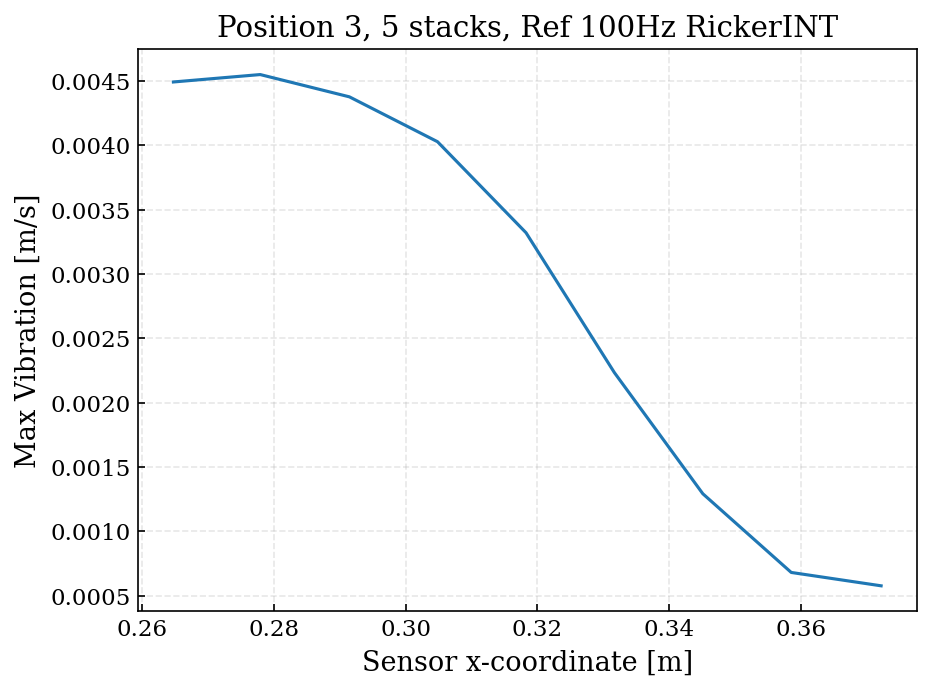

In [3]:
vib_x = detrend(vib_x, axis=0, type="constant")
vib_x_max = (vib_z).max()
plt.plot(x_raw, vib_x.max(axis=0))
#plt.plot(x_raw, vib_x.min(axis=0))
plt.xlabel("Sensor x-coordinate [m]")
plt.ylabel("Max Vibration [m/s]")
plt.title("Position 3, 5 stacks, Ref 100Hz RickerINT")
#vib_x_max = (vib_x).max()
#print(f"Max vib_x value: {vib_x_max:.6f} m/s")
# Find and plot the time and value of the maximum vibration for each sensor
#vib_x_max_time = t[np.argmax(vib_x, axis=0)]
#plt.scatter(vib_x_max_time, vib_x_max, color='red', s=20, label='Max Vibration')
#plt.plot(vib_x)

#plt.plot(x_raw,vib_x_max_time)
#plt.xlim(0,1.6)
#plt.ylim(0.0,0.1)


In [4]:
y_raw

array([0.02112191, 0.02117207, 0.0211447 , 0.0210867 , 0.0210446 ,
       0.02090412, 0.02089834, 0.02086231, 0.02073698])

Text(0.5, 0, 'Time [samples]')

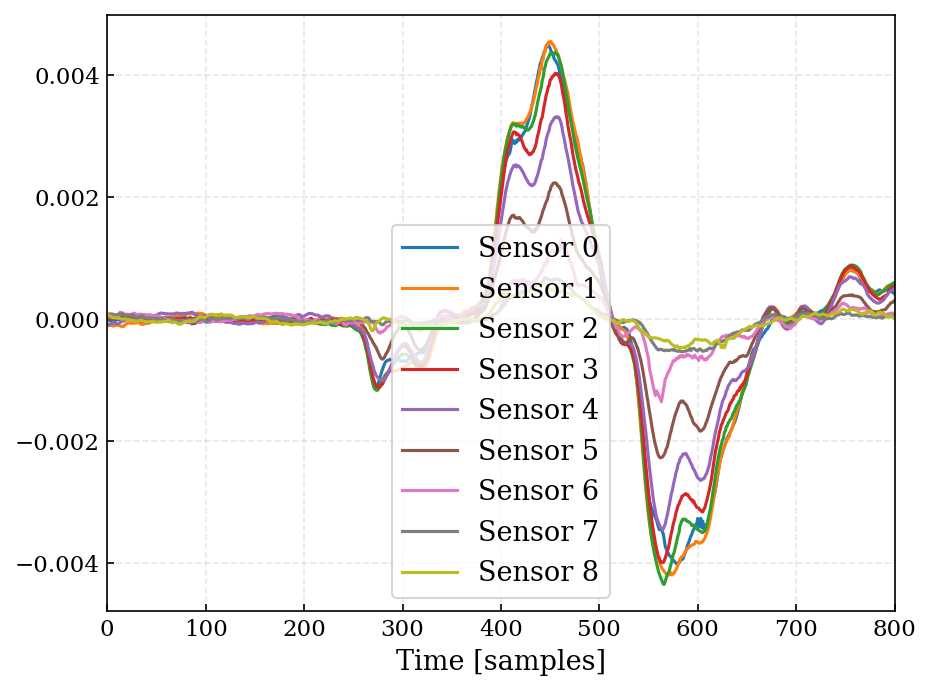

In [5]:
# plot every 5th sensor
plt.plot(vib_x[:, :])
plt.xlim(0, 800)
#plt.ylim(0.013,0.017)
plt.legend([f"Sensor {i}" for i in range(0, vib_x.shape[1], 1)])
plt.xlabel("Time [samples]")

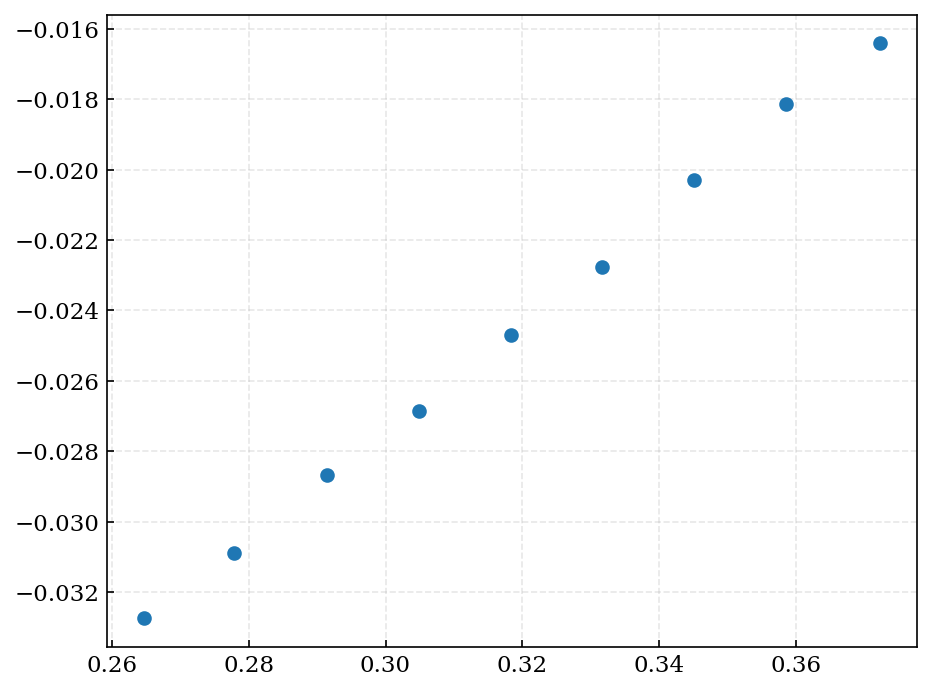

In [6]:
plt.plot(x_raw, z_raw, "o")

In [10]:
x_raw

array([0.26471427, 0.2779032 , 0.29144618, 0.30483222, 0.3182781 ,
       0.33169729, 0.3451288 , 0.35855874, 0.37220973])

In [11]:
x_raw[-1] - x_raw[0]

np.float64(0.10749545693397522)

---
## Section 2 — Optional Bandpass Filtering

A zero-phase **Butterworth bandpass** filter (identical to MATLAB's `filtfilt`) is applied along the time axis.  
Set `APPLY_FILTER = False` to skip this step.

> **Why zero-phase?**  `filtfilt` applies the filter forward and backward, so there is no phase distortion — especially important for wavefield data where the phase carries travel-time information.

In [7]:
from scipy.signal import sosfiltfilt

# ── Filter Configuration ─────────────────────────────────────────────────
APPLY_FILTER  = False            # set to False to skip
FILTER_TYPE   = "lowpass"      # "bandpass" or "lowpass"
F_LOW         = 250               # low-cut frequency [Hz]   (bandpass only)
F_HIGH        = 30             # high-cut frequency [Hz]  (bandpass / lowpass)
FILTER_ORDER  = 3               # Butterworth order
# ─────────────────────────────────────────────────────────────────────────


def apply_butter_filter(data: np.ndarray, fs: float,
                        f_low: float | None = None,
                        f_high: float | None = None,
                        order: int = 3,
                        filter_type: str = "bandpass") -> np.ndarray:
    """Apply a zero-phase Butterworth filter along axis 0 (time)."""
    nyq = fs / 2.0

    if filter_type == "bandpass":
        if f_low is None or f_high is None:
            raise ValueError("Bandpass filter requires both f_low and f_high.")
        wn = [f_low / nyq, f_high / nyq]
        btype = "bandpass"

    elif filter_type == "lowpass":
        if f_high is None:
            raise ValueError("Lowpass filter requires f_high.")
        wn = f_high / nyq
        btype = "lowpass"

    else:
        raise ValueError("filter_type must be 'bandpass' or 'lowpass'.")

    wn_arr = np.atleast_1d(wn)
    if np.any(wn_arr <= 0) or np.any(wn_arr >= 1):
        raise ValueError("Cutoff frequencies must satisfy 0 < Wn < fs/2.")
    if filter_type == "bandpass" and f_low >= f_high:
        raise ValueError("For bandpass, f_low must be smaller than f_high.")

    sos = butter(order, wn, btype=btype, output="sos")
    return sosfiltfilt(sos, data, axis=0)


# Keep raw copies for spectral comparison later
vx_raw = vx.copy()
vy_raw = vy.copy()
vz_raw = vz.copy()

if APPLY_FILTER:
    vx = apply_butter_filter(vx, fs, F_LOW, F_HIGH, FILTER_ORDER, FILTER_TYPE)
    vy = apply_butter_filter(vy, fs, F_LOW, F_HIGH, FILTER_ORDER, FILTER_TYPE)
    vz = apply_butter_filter(vz, fs, F_LOW, F_HIGH, FILTER_ORDER, FILTER_TYPE)

    if FILTER_TYPE == "bandpass":
        print(f"Bandpass filter applied: {F_LOW}–{F_HIGH} Hz  (order {FILTER_ORDER})")
    else:
        print(f"Lowpass filter applied: f < {F_HIGH} Hz  (order {FILTER_ORDER})")
else:
    print("Filtering skipped.")

Filtering skipped.


---
## Section 3 — Space–Time Waveform Plots

Each panel shows **velocity as a function of time (vertical axis) and sensor position (horizontal axis)** — the standard *record section* or *shot gather* display in seismology.  
The colorscale is symmetric around zero and clipped to ±50 % of the global maximum of `v_z` (the dominant component in bending-wave experiments).

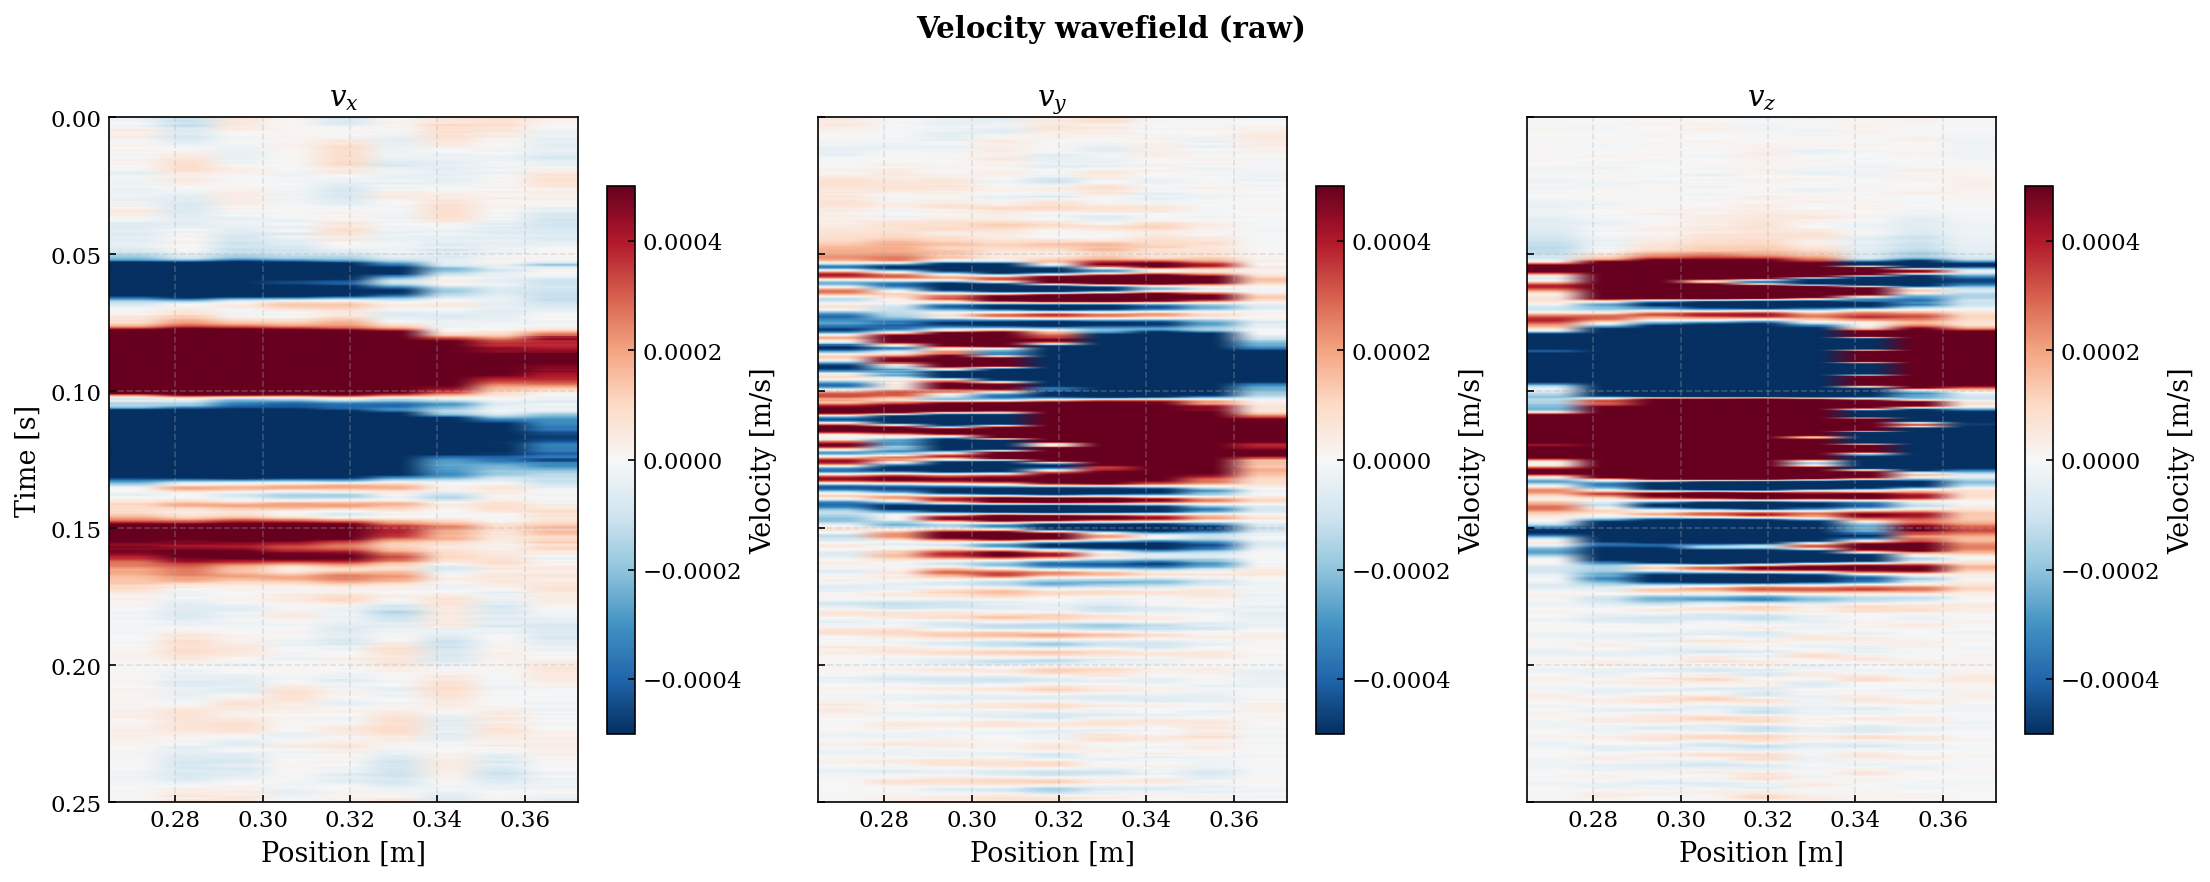

In [8]:
def plot_wavefield(x: np.ndarray, t: np.ndarray,
                   components: dict,
                   clim: float | None = None,
                   t_min: float = 0.0, t_max: float | None = None,
                   label_unit: str = "Velocity [m/s]",
                   suptitle: str = "Velocity wavefield") -> None:
    """Plot space–time images for an arbitrary number of velocity components.

    Parameters
    ----------
    x          : sensor positions (N_sensors,) [m]
    t          : time vector (N_samples,) [s]
    components : dict mapping label → 2-D array (N_samples × N_sensors)
    clim       : symmetric colour limit; auto if None
    t_min/max  : time-axis limits [s]
    suptitle   : figure title
    """
    n = len(components)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6), sharey=True)
    if n == 1:
        axes = [axes]

    # Auto colour limit: 25 % of the maximum across all components
    if clim is None:
        clim = 0.25 * max(np.abs(arr).max() for arr in components.values())

    t_max_plot = t_max if t_max is not None else t[-1]

    for ax, (label, data) in zip(axes, components.items()):
        im = ax.imshow(
            data,
            aspect="auto",
            origin="upper",
            extent=[x[0], x[-1], t[-1], t[0]],   # [left, right, bottom, top]
            vmin=-clim, vmax=clim,
        )
        ax.set_ylim(t_max_plot, t_min)             # flip y so t increases downward
        ax.set_xlabel("Position [m]")
        ax.set_title(label)

        vlines_x = None #[0.95, 1.0] #[0.35, 0.4, 0.95, 1.0, 1.55, 1.60]  # example positions for vertical lines

        ax.vlines(vlines_x, t_min, t_max_plot, colors='lightgray', linestyles='dashed')

        plt.colorbar(im, ax=ax, label=label_unit, shrink=0.8)

    axes[0].set_ylabel("Time [s]")
    fig.suptitle(suptitle, fontsize=14, fontweight="bold")
    #plt.ylim(4.02, 4.)


    plt.tight_layout()
    plt.show()

T_MIN = 0.0 #6.2090
T_MAX = 0.25 #42 #6.3000

# Plot all three velocity components
plot_wavefield(
    x_raw, t,
    components={"$v_x$": vx, "$v_y$": vy, "$v_z$": vz}, clim= 0.5*1e-3, # None
    t_min=T_MIN, t_max=T_MAX,
    suptitle="Velocity wavefield (after filtering: {}–{} Hz)".format(F_LOW, F_HIGH) if APPLY_FILTER else "Velocity wavefield (raw)",
)

In [9]:
x_raw

array([0.26471427, 0.2779032 , 0.29144618, 0.30483222, 0.3182781 ,
       0.33169729, 0.3451288 , 0.35855874, 0.37220973])

---
## Section 4 — Amplitude Spectra (FFT)

The **amplitude spectrum** is computed by taking the real FFT along the time axis, averaged across all sensors.  
Comparing the **raw** and **filtered** spectrum lets you verify that the bandpass has the desired effect and that no important signal content lies outside the pass band.

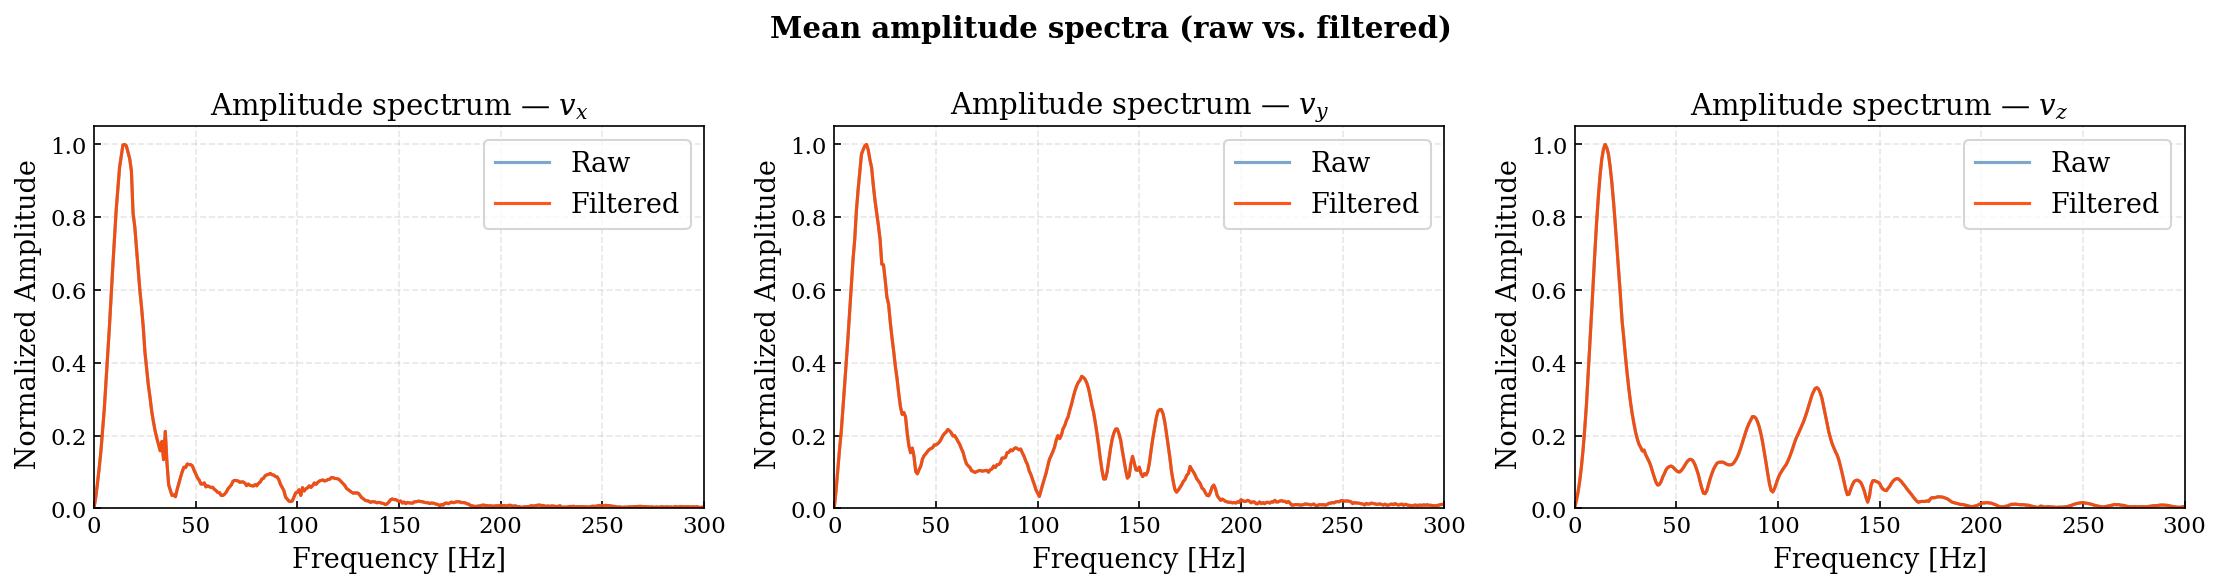

In [10]:
def mean_amplitude_spectrum(data: np.ndarray, fs: float) -> tuple[np.ndarray, np.ndarray]:
    """Compute the mean single-sided amplitude spectrum along the time axis.

    Parameters
    ----------
    data : 2-D array (N_samples × N_sensors)
    fs   : sampling frequency [Hz]

    Returns
    -------
    freqs : frequency vector (N_freq,) [Hz]
    amp   : mean amplitude (N_freq,)
    """
    N = data.shape[0]
    # rfft returns the positive-frequency half; normalise by N
    spec = np.abs(np.fft.rfft(data, axis=0)) / N
    # Double the one-sided amplitude (except DC and Nyquist)
    spec[1:-1] *= 2
    freqs = np.fft.rfftfreq(N, d=1.0 / fs)
    return freqs, spec.mean(axis=1)


freqs, amp_raw = mean_amplitude_spectrum(vx_raw, fs)   # raw — unfiltered vx as example
freqs, amp_flt = mean_amplitude_spectrum(vx, fs)        # filtered vx

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, raw, flt, comp in zip(
    axes,
    [vx_raw, vy_raw, vz_raw],
    [vx,     vy,     vz],
    ["$v_x$", "$v_y$", "$v_z$"],
):
    f_r, a_r = mean_amplitude_spectrum(raw, fs)
    f_f, a_f = mean_amplitude_spectrum(flt, fs)

    # --- Option A: Logarithmic (Current) ---
    #ax.semilogy(f_r, a_r, color="steelblue", alpha=0.7, label="Raw")
    #ax.semilogy(f_f, a_f, color="orangered", alpha=0.9, label="Filtered")

    # --- Option B: Linear Normalized ---
    norm = np.max(a_r)
    ax.plot(f_r, a_r / norm, color="steelblue", alpha=0.7, label="Raw")
    ax.plot(f_f, a_f / norm, color="orangered", alpha=0.9, label="Filtered")

    if APPLY_FILTER:
        # Shade the rejected bands
        ax.axvspan(0,      F_LOW,  color="gray", alpha=0.15)
        ax.axvspan(F_HIGH, fs / 2, color="gray", alpha=0.15)
        ax.axvline(F_LOW,  color="k", ls="--", lw=0.8)
        ax.axvline(F_HIGH, color="k", ls="--", lw=0.8)

    ax.set_xlim(0, min(fs / 2,300))
    ax.set_xlabel("Frequency [Hz]")
    # --- Option A
    #ax.set_ylabel("Amplitude [m/s]")
    #ax.set_ylim(1e-6, 1e-3)
    # --- Option B
    ax.set_ylabel(" Normalized Amplitude")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Amplitude spectrum — {comp}")
    ax.set_title(f"Amplitude spectrum — {comp}")    
    ax.legend()
    ax.grid(True, which="both", ls="--", alpha=0.3)


fig.suptitle("Mean amplitude spectra (raw vs. filtered)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
# Find the dominant frequency in the raw signal for each component
for comp, raw in zip(["v_x", "v_y", "v_z"], [vx_raw, vy_raw, vz_raw]):
    f_r, a_r = mean_amplitude_spectrum(raw, fs)
    dominant_freq = f_r[np.argmax(a_r)]
    print(f"Dominant frequency in {comp} (raw): {dominant_freq:.2f} Hz")

Dominant frequency in v_x (raw): 15.00 Hz
Dominant frequency in v_y (raw): 15.83 Hz
Dominant frequency in v_z (raw): 15.00 Hz


In [12]:
from scipy import signal

def compute_spectrogram(data_1d: np.ndarray, fs: float, nperseg: int = 1024, noverlap: int = 512) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute the spectrogram of a single 1D time series.

    Parameters
    ----------
    data_1d : 1-D array (N_samples,)
    fs      : sampling frequency [Hz]
    nperseg : length of each segment (resolution parameter)
    noverlap: number of points to overlap between segments

    Returns
    -------
    f   : Array of sample frequencies [Hz]
    t   : Array of segment times [s]
    Sxx : Spectrogram (power spectral density) [f x t]
    """
    f, t_spec, Sxx = signal.spectrogram(data_1d, fs, nperseg=nperseg, noverlap=noverlap)
    return f, t_spec, Sxx

IndexError: index 10 is out of bounds for axis 1 with size 9

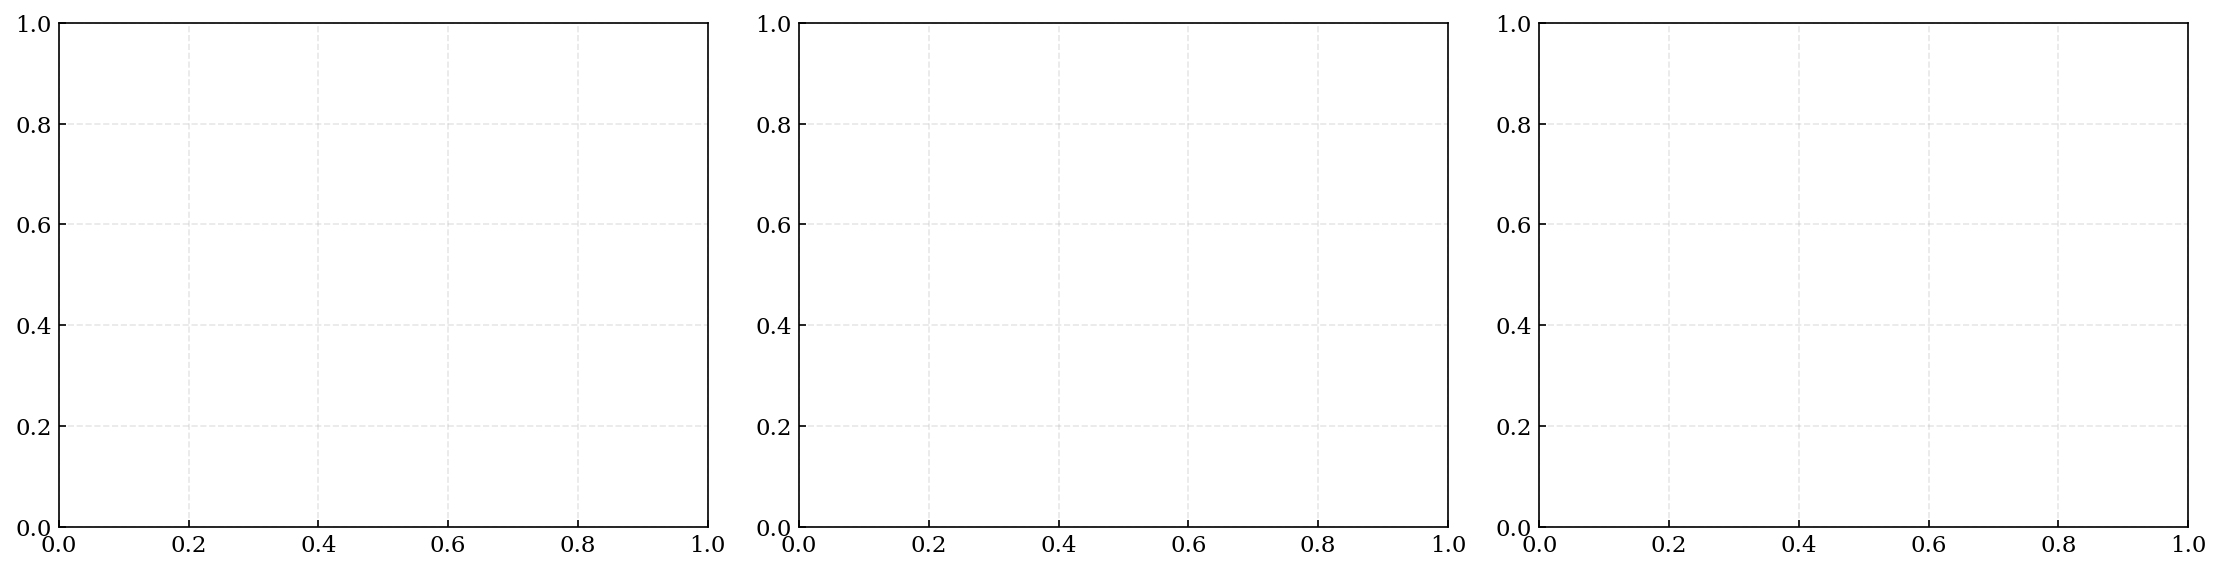

In [13]:
# --- Configuration for Spectrogram ---
SENSOR_IDX = 10        # Choose which sensor index to plot
NPERSEG = 1024        # Window size (higher = better frequency res, worse time res)
NOVERLAP = 512        # Overlap (higher = smoother in time axis)
F_MAX = 600           # Maximum frequency to display on y-axis

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, raw_data, comp in zip(
    axes,
    [vx_raw, vy_raw, vz_raw],
    ["$v_x$", "$v_y$", "$v_z$"],
):
    # Extract the 1D time series for the chosen sensor
    sensor_data = raw_data[:, SENSOR_IDX]

    # Compute spectrogram
    f, t_spec, Sxx = compute_spectrogram(sensor_data, fs, nperseg=NPERSEG, noverlap=NOVERLAP)

    # Convert to Decibels for better visualization of wide dynamic ranges
    # Adding a tiny epsilon (1e-12) prevents log10(0) warnings
    Sxx_db = 10 * np.log10(Sxx + 1e-12)

    # Plot the spectrogram
    # 'shading="gouraud"' smooths the pixels. Remove it if you want crisp blocks.
    im = ax.pcolormesh(t_spec, f, Sxx_db, shading='gouraud', cmap='viridis')

    # Formatting
    ax.set_ylim(0, min(fs / 2, F_MAX))
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(f"Spectrogram — {comp}")

    # Add a colorbar to each subplot to show the dB scale
    fig.colorbar(im, ax=ax, label="Power [dB]")


fig.suptitle(f"Spectrograms for Sensor Index {SENSOR_IDX}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

FFT for each position

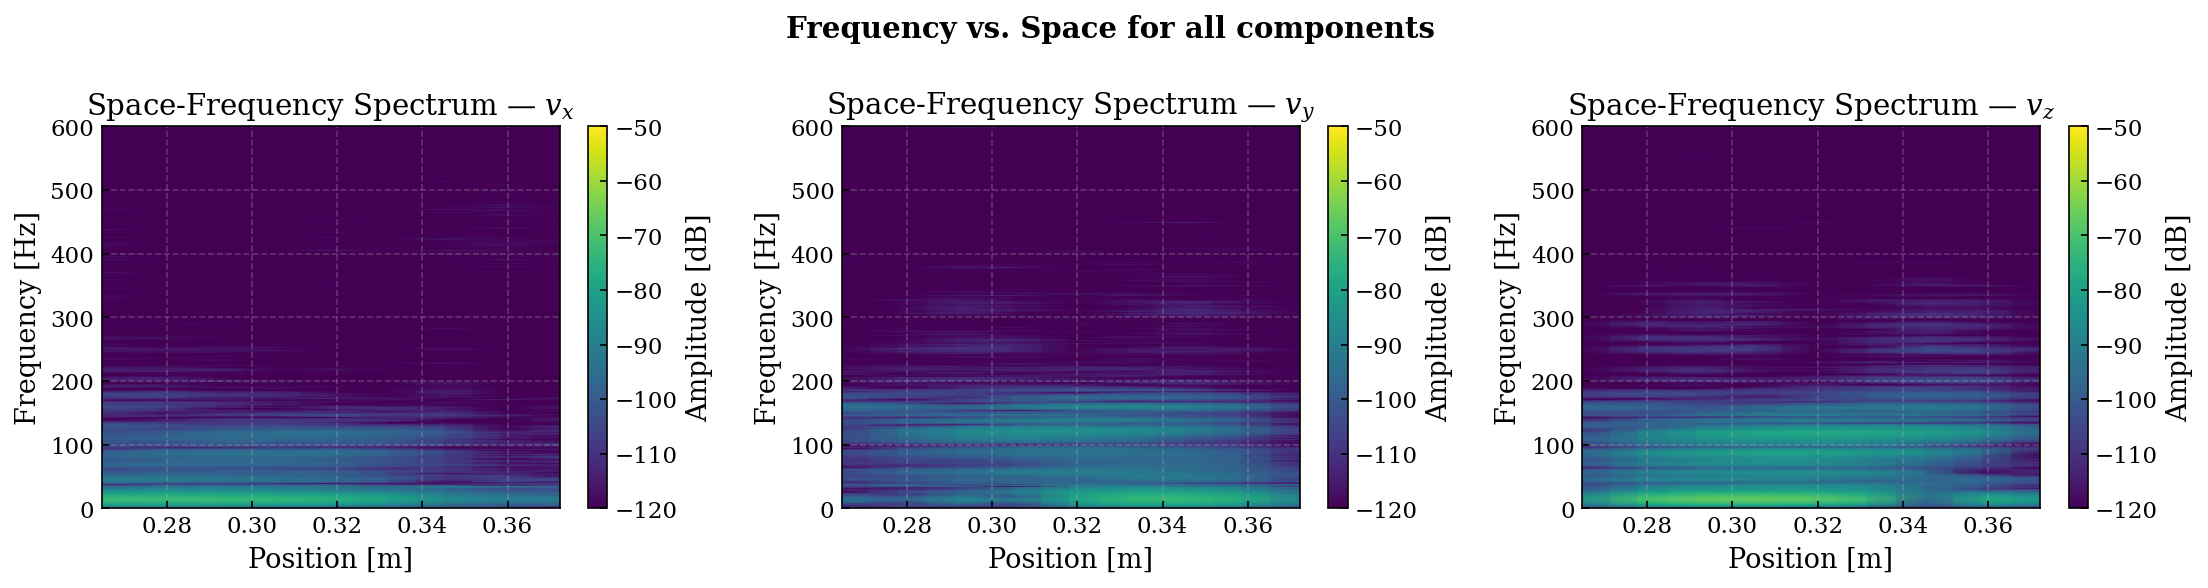

In [14]:
def compute_space_frequency_spectrum(data: np.ndarray, fs: float) -> tuple[np.ndarray, np.ndarray]:
    """Compute the amplitude spectrum for each sensor along the time axis.
    
    Parameters
    ----------
    data : 2-D array (N_samples × N_sensors)
    fs   : sampling frequency [Hz]
    
    Returns
    -------
    freqs : frequency vector (N_freq,) [Hz]
    spec  : 2-D amplitude spectrum (N_freq × N_sensors)
    """
    N = data.shape[0]
    # rfft returns the positive-frequency half
    spec = np.abs(np.fft.rfft(data, axis=0)) / N
    # Double the one-sided amplitude (except DC and Nyquist)
    spec[1:-1] *= 2
    freqs = np.fft.rfftfreq(N, d=1.0 / fs)
    return freqs, spec

# --- Configuration for Space-Frequency Plot ---
F_MAX = 600           # Maximum frequency to display on y-axis

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, raw_data, comp in zip(
    axes,
    [vx_raw, vy_raw, vz_raw],
    ["$v_x$", "$v_y$", "$v_z$"],
):
    # Compute spectrum for all sensors
    f, Sxx_space = compute_space_frequency_spectrum(raw_data, fs)
    
    # Convert amplitude to Decibels for better visualization
    # Since this is amplitude (not power), we use 20 * log10
    Sxx_db = 20 * np.log10(Sxx_space + 1e-12)
    
    # Plot the 2D mesh
    # x_raw has shape (N_sensors,), f has shape (N_freqs,)
    # Sxx_db has shape (N_freqs, N_sensors)
    im = ax.pcolormesh(x_raw, f, Sxx_db, shading='gouraud', cmap='viridis', vmin=-120, vmax=-50)
    
    # Formatting
    ax.set_ylim(0, min(fs / 2, F_MAX))
    ax.set_xlabel("Position [m]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(f"Space-Frequency Spectrum — {comp}")
    
    # Add a colorbar to each subplot to show the dB scale
    fig.colorbar(im, ax=ax, label="Amplitude [dB]")

fig.suptitle("Frequency vs. Space for all components", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 5 — Frequency–Wavenumber (FK) Spectrum

The **double Fourier transform** of the space–time wavefield $u(x, t)$ yields the FK spectrum $\hat{u}(k, f)$:

$$\hat{u}(k, f) = \int\!\int u(x, t)\, e^{-i 2\pi (ft - kx)}\,\mathrm{d}t\,\mathrm{d}x$$

* The **slope** of energy ridges in the FK plane is the **phase velocity** $c = f / k$.
* **Aliasing** in the wavenumber dimension occurs when $k > 1 / (2\,\Delta x)$ (spatial Nyquist).
* The amplitude is shown on a **logarithmic (dB) scale** to make low-energy modes visible alongside dominant ones.

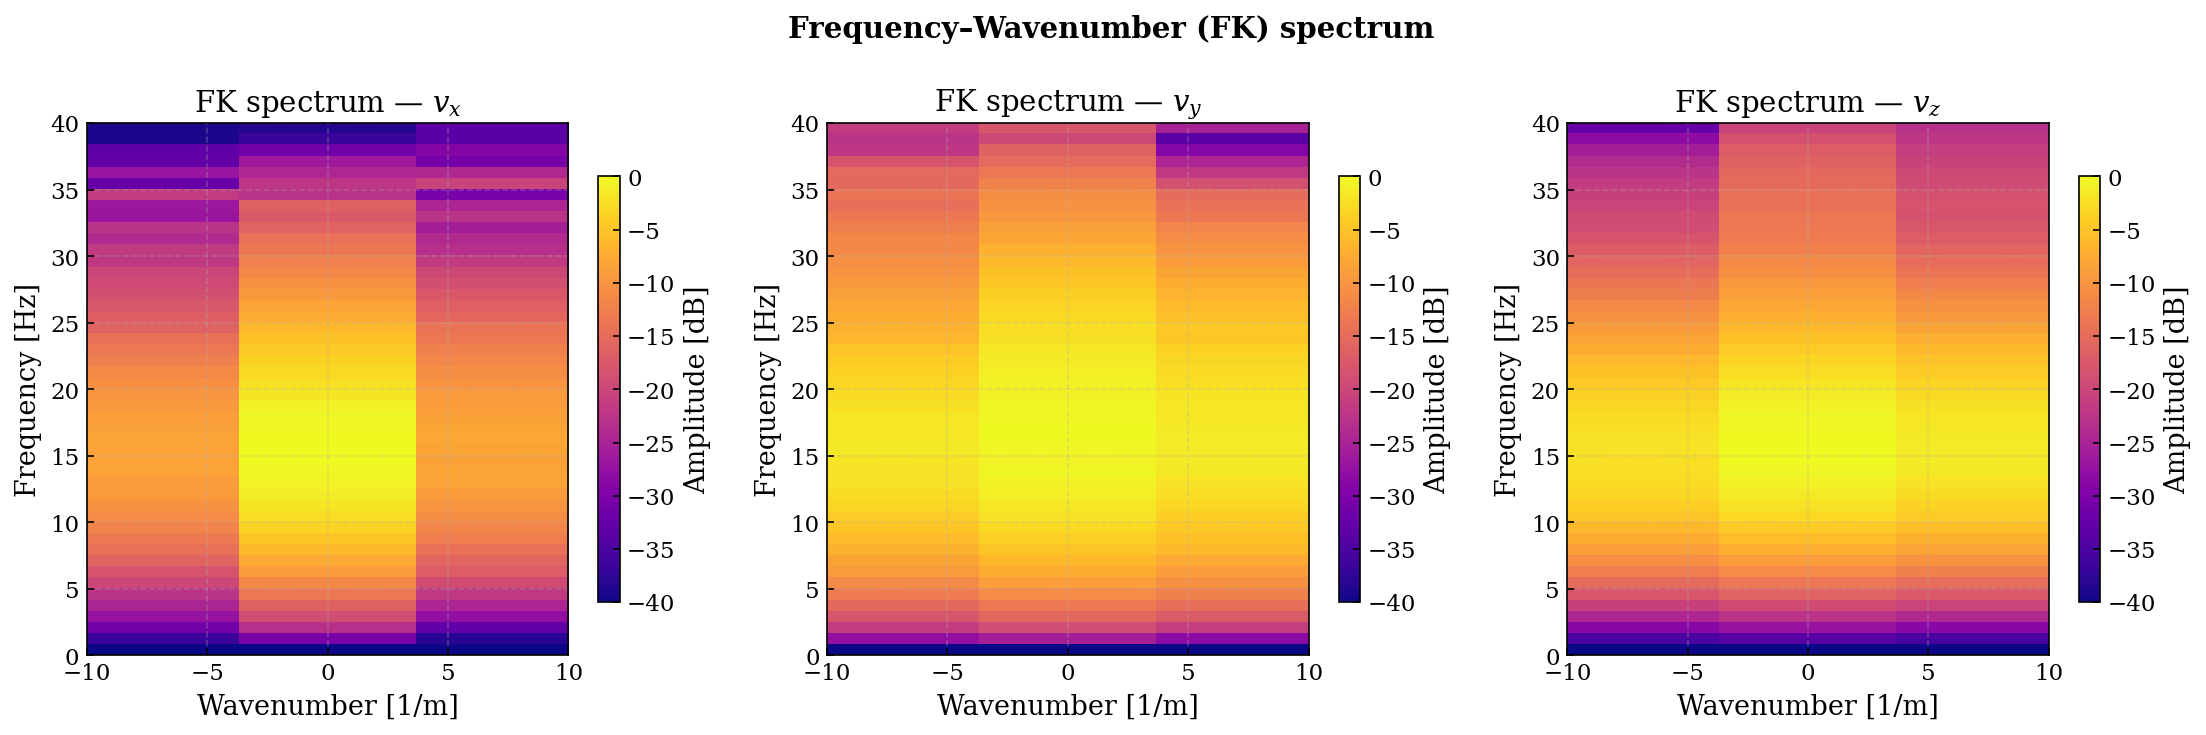

In [15]:
def fk_spectrum(data: np.ndarray, fs: float, dx: float,
                db_clip: float = 40.0) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute the 2-D FK (frequency–wavenumber) power spectrum.

    The 2-D FFT is applied: first along time (axis 0), then along space (axis 1).
    Only the positive-frequency half is returned (using rfft along time).

    Parameters
    ----------
    data    : 2-D array (N_samples × N_sensors)
    fs      : sampling frequency [Hz]
    dx      : sensor spacing [m]  (may be non-uniform mean)
    db_clip : dynamic range to display [dB]  (clip floor = peak − db_clip)

    Returns
    -------
    freqs : frequency axis (N_freq,)   [Hz]
    ks    : wavenumber axis (N_x,)     [1/m]  — centred (0 in middle)
    spec  : amplitude in dB, shape (N_freq × N_x)
    """
    Nt, Nx = data.shape
    # FFT along time → positive frequencies; then FFT along space (full, centred)
    FK = np.fft.rfft(data, axis=0)        # (N_freq × Nx)
    FK = np.fft.fft(FK, axis=1)           # (N_freq × Nx)
    FK = np.fft.fftshift(FK, axes=1)      # centre wavenumber axis

    spec = np.abs(FK)
    # Convert to dB, clip dynamic range
    spec_db = 20 * np.log10(spec / spec.max() + 1e-12)
    spec_db = np.clip(spec_db, -db_clip, 0)

    freqs = np.fft.rfftfreq(Nt, d=1.0 / fs)
    ks    = np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))

    return freqs, ks, spec_db


# Compute FK spectra for all three components
fk_results = {}
for label, data in [("$v_x$", vx), ("$v_y$", vy), ("$v_z$", vz)]:
    freqs_fk, ks, fk_db = fk_spectrum(data, fs, dx, db_clip=40)
    fk_results[label] = fk_db

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, fk_db) in zip(axes, fk_results.items()):
    im = ax.imshow(
        fk_db,
        aspect="auto",
        origin="lower",
        extent=[ks[0], ks[-1], freqs_fk[0], freqs_fk[-1]],
        cmap="plasma",
        vmin=-40, vmax=0,
    )
    ax.set_xlim(ks[0], ks[-1])
    ax.set_xlim(-10, 10)
    ax.set_ylim(0, min(fs / 2, 40))
    ax.set_xlabel("Wavenumber [1/m]")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title(f"FK spectrum — {label}")
    plt.colorbar(im, ax=ax, label="Amplitude [dB]", shrink=0.8)

fig.suptitle("Frequency–Wavenumber (FK) spectrum", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 6 — Strain

**Strain** $\varepsilon$ is the spatial derivative of displacement $u$:

$$\varepsilon(x, t) = \frac{\partial u}{\partial x}$$

**Workflow:**

1. **Integrate velocity → displacement** along the time axis using the trapezoidal rule:
   $$u(x, t) = \int_0^t v(x, \tau)\,\mathrm{d}\tau$$
2. **Differentiate displacement along the x-axis** using a second-order central finite-difference scheme.

> **Note on the integration constant:** `cumulative_trapezoid` with `initial=0` sets $u(x, 0) = 0$.  
> Any DC drift in the velocity (e.g. from instrument noise) will appear as a ramp in displacement.  
> The bandpass filter already removes the DC component, so this is usually not an issue here.

Mean dx: 0.013437 m; Max deviation: 2.48e-04 m
Displacement and strain computed.
  Peak |ε_x|: 2.554e-03 m/m


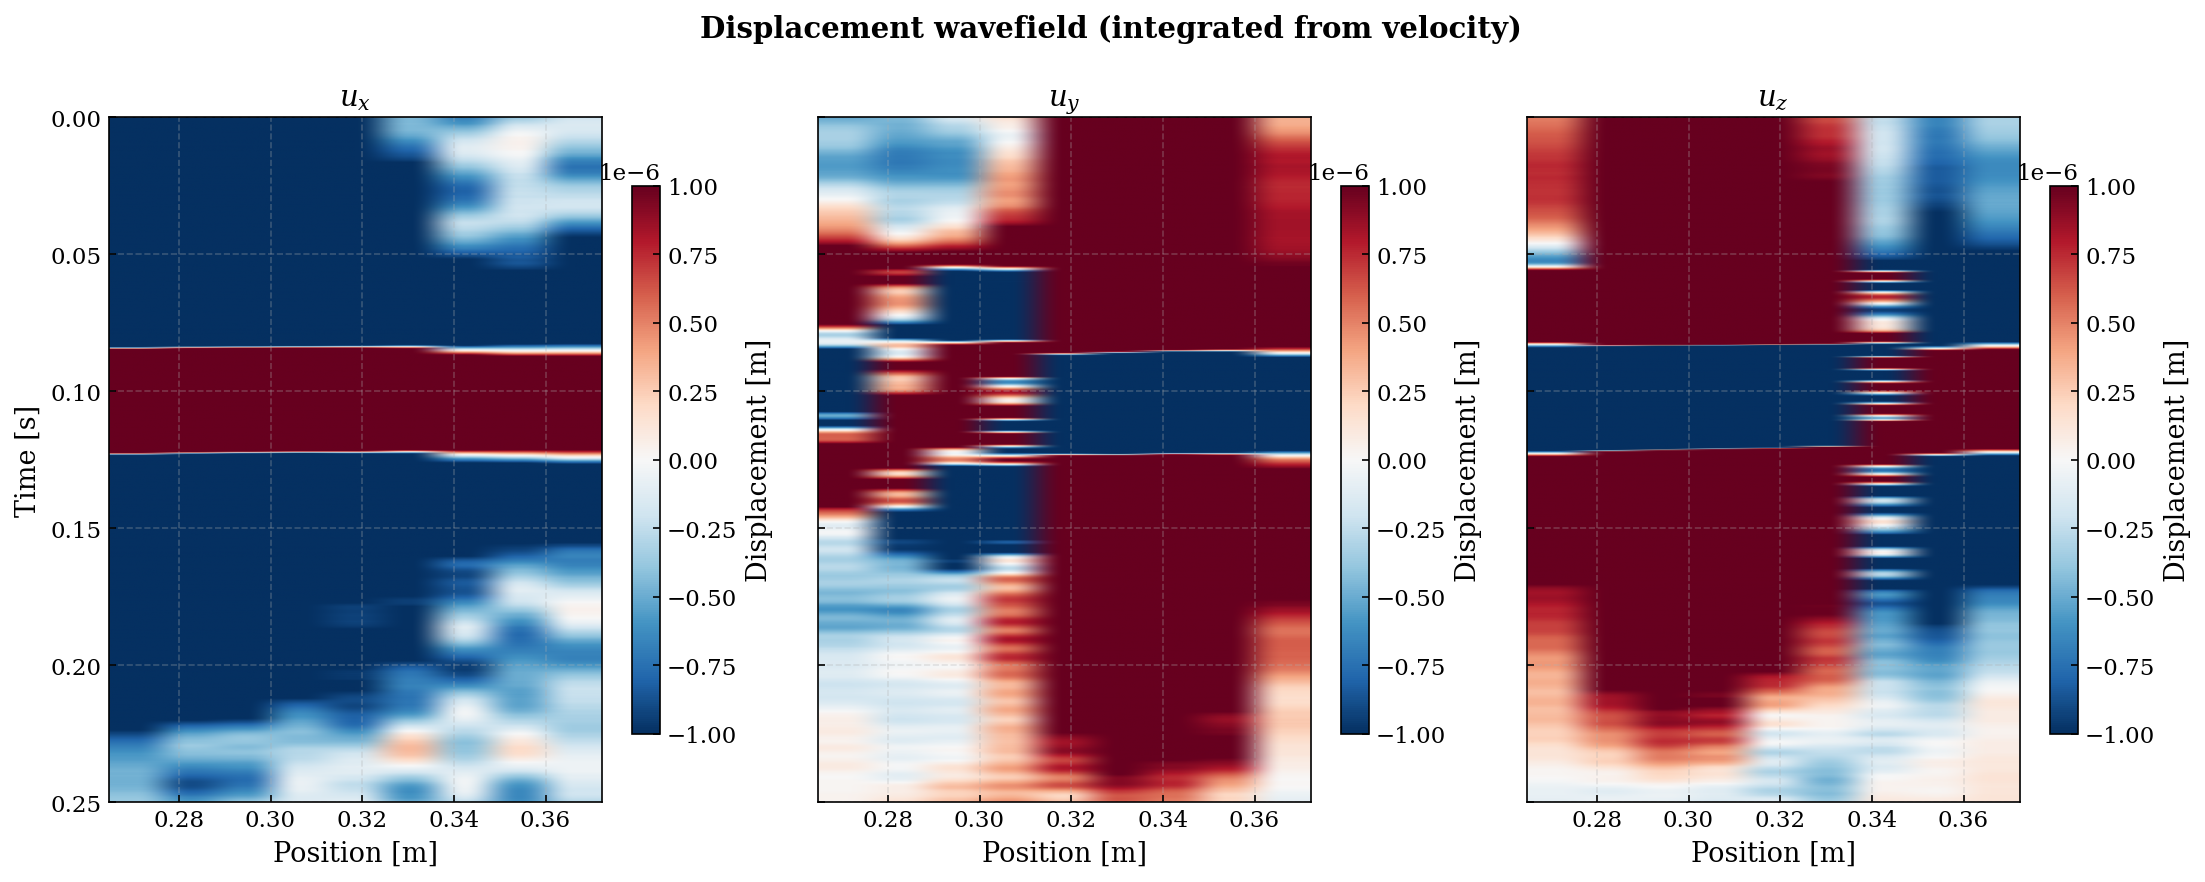

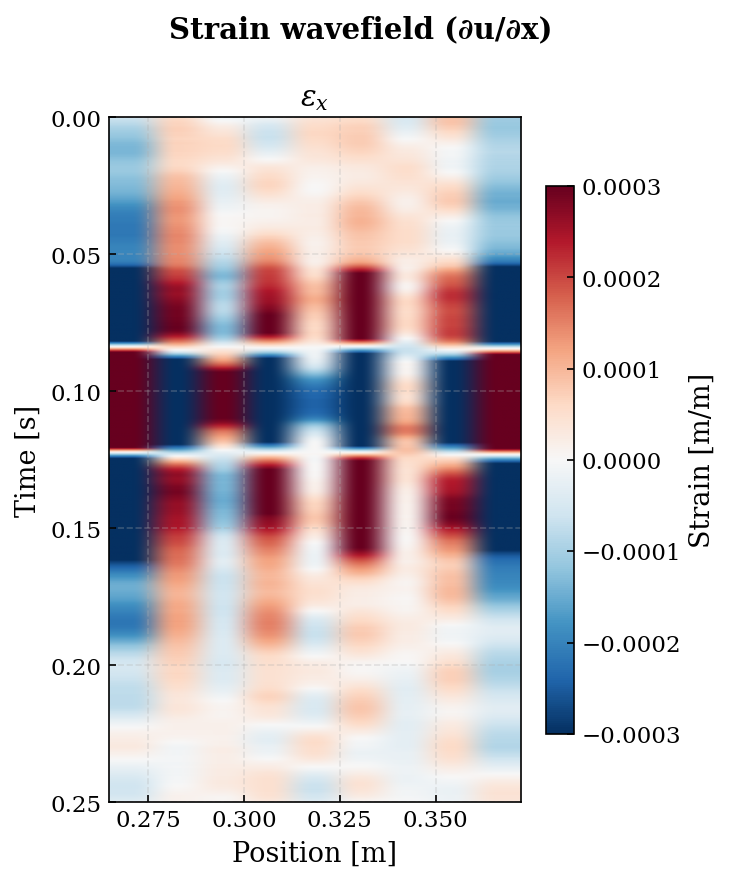

In [17]:
def velocity_to_displacement(
    vel: np.ndarray,
    dt: float,
    method: str = "freq",
    fmin: float = 5.0,
) -> np.ndarray:
    """Integrate velocity to displacement along axis 0 (time).

    Parameters
    ----------
    vel : 2-D array (N_samples × N_sensors) [m/s]
    dt  : time step [s]
    method : "freq" (recommended) or "trapz"
        - "freq": frequency-domain integration with low-frequency regularization
        - "trapz": cumulative trapezoidal integration
    fmin : float
        Minimum frequency [Hz] used in "freq" mode to avoid low-frequency noise blow-up.

    Returns
    -------
    disp : 2-D array (N_samples × N_sensors) [m]
    """
    v = vel # detrend(vel, axis=0, type="linear") # optional detrending to remove linear drift before integration

    if method == "trapz":
        return cumulative_trapezoid(v, dx=dt, axis=0, initial=0)

    if method == "freq":
        n = v.shape[0]
        freqs = np.fft.rfftfreq(n, d=dt)
        omega = 2 * np.pi  * np.maximum(freqs, fmin)  # regularized denominator

        V = np.fft.rfft(v, axis=0)
        U = V / (1j * omega[:, None])
        U[0, :] = 0.0  # enforce zero-mean displacement

        u = np.fft.irfft(U, n=n, axis=0)
        return detrend(u, axis=0, type="constant")  # remove residual offset

    raise ValueError("method must be 'freq' or 'trapz'")


def spatial_gradient(
    field: np.ndarray,
    x: np.ndarray,
    method: str = "wavenumber",
    use_mean_dx: bool = True,
    rtol_dx: float = 5e-6,
) -> np.ndarray:
    """Compute spatial gradient ∂field/∂x along axis 1 (space).

    Parameters
    ----------
    field : 2-D array (N_samples × N_sensors)
    x     : sensor positions (N_sensors,) [m]
    method : "finite" or "wavenumber"
        - "finite": np.gradient with non-uniform spacing (2nd-order interior)
        - "wavenumber": spectral derivative in k-domain (assumes ~uniform spacing)
    use_mean_dx : bool
        If True, use mean spacing for "wavenumber" even when x is slightly non-uniform.
        If False, raise an error when spacing is non-uniform.
    rtol_dx : float
        Relative tolerance for spacing non-uniformity check in "wavenumber" mode.

    Returns
    -------
    grad : 2-D array (N_samples × N_sensors)
    """
    if method == "finite":
        return np.gradient(field, x, axis=1, edge_order=2)

    if method == "wavenumber":
        dx_all = np.diff(x)
        dx_mean = dx_all.mean()
        nonuniform = np.any(np.abs(dx_all - dx_mean) > rtol_dx * dx_mean)

        print(f"Mean dx: {dx_mean:.6f} m; Max deviation: {np.abs(dx_all - dx_mean).max():.2e} m")

        if nonuniform and not use_mean_dx:
            raise ValueError(
                "x is non-uniform; wavenumber method requires uniform spacing "
                "(or set use_mean_dx=True)."
            )
        if nonuniform and use_mean_dx:
            print("Warning: x is non-uniform; using mean dx for wavenumber gradient.")

        F = np.fft.fft(field, axis=1)  # along sensors
        k = np.fft.fftfreq(field.shape[1], d=dx_mean)  # cycles/m
        grad = np.fft.ifft((1j * 2 * np.pi * k)[None, :] * F, axis=1).real
        return grad

    raise ValueError("method must be 'finite' or 'wavenumber'")


dt = t[1] - t[0]   # time step [s]

# ── Displacement by integration of velocity (time axis) ──────────────────
ux = velocity_to_displacement(vx, dt)   # (N_samples × N_sensors)  [m]
uy = velocity_to_displacement(vy, dt)
uz = velocity_to_displacement(vz, dt)

# ── Strain: spatial gradient of displacement ──────────────────────────────
strain_x = spatial_gradient(ux, x_raw)     # ε_x = ∂u_x/∂x
#strain_y = spatial_gradient(uy, x_raw)     # ε_y = ∂u_y/∂x
#strain_z = spatial_gradient(uz, x_raw)     # ε_z = ∂u_z/∂x  (bending strain proxy)

# look only at every second sensor to avoid edge artifacts in gradient
#ux = ux[:, ::2]
#strain_x = strain_x[:, ::2]
#strain_y = strain_y[:, ::2]
#strain_z = strain_z[:, ::2]

# normalize amplitudes 
#ux /= np.abs(ux).max()
#strain_x /= np.abs(strain_x).max()


print("Displacement and strain computed.")
print(f"  Peak |ε_x|: {np.abs(strain_x).max():.3e} m/m")

# ── Plot displacement wavefields ──────────────────────────────────────────
plot_wavefield(
    x_raw, t,
    components={"$u_x$": ux, "$u_y$": uy, "$u_z$": uz},
    clim=1e-6,
    t_min=T_MIN, t_max=T_MAX,
    #t_min=4.00, t_max=4.020,
    label_unit="Displacement [m]",
    suptitle="Displacement wavefield (integrated from velocity)",
)

# ── Plot strain wavefields ────────────────────────────────────────────────
plot_wavefield(
    x_raw, t,
    components={"$\\varepsilon_x$": strain_x}, # "$\\varepsilon_y$": strain_y, "$\\varepsilon_z$": strain_z},
    clim=0.3 * 1e-3,
    #clim=1e-6,
    t_min=T_MIN, t_max=T_MAX,
    #t_min=4.00, t_max=4.020,
    label_unit="Strain [m/m]",
    suptitle="Strain wavefield (∂u/∂x)",
)

Text(0.5, 0, 'Sensor x-coordinate [m]')

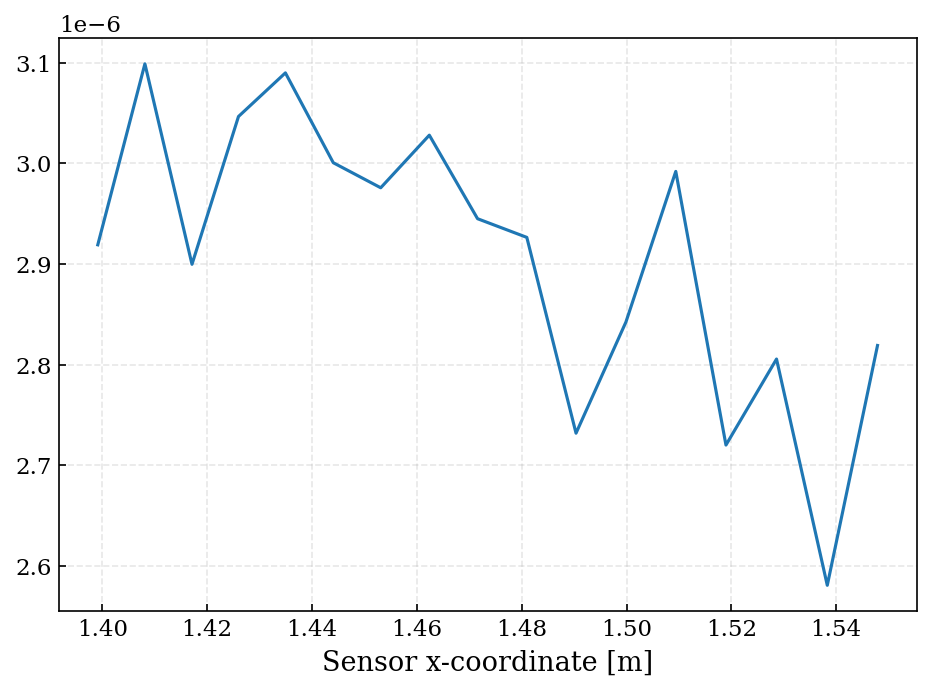

In [46]:
# detrend
ux = detrend(ux, axis=0, type="constant")
plt.plot(x_raw, ux.max(axis=0))
#plt.plot(x_raw, ux.min(axis=0))
plt.xlabel("Sensor x-coordinate [m]")
#ux_max = (ux).max()
#print(f"Max ux value: {ux_max:.6f} m")
#plt.plot(ux)


In [47]:
fmin = 300.0
bob = np.maximum(freqs, fmin)
print(bob)
np.shape(bob)

[ 300.  300.  300. ... 4990. 4995. 5000.]


(1001,)

Mean dx: 0.009299 m; Max deviation: 4.29e-04 m
Displacement and strain computed.
  Peak |ε_x|: 3.102e-05 m/m


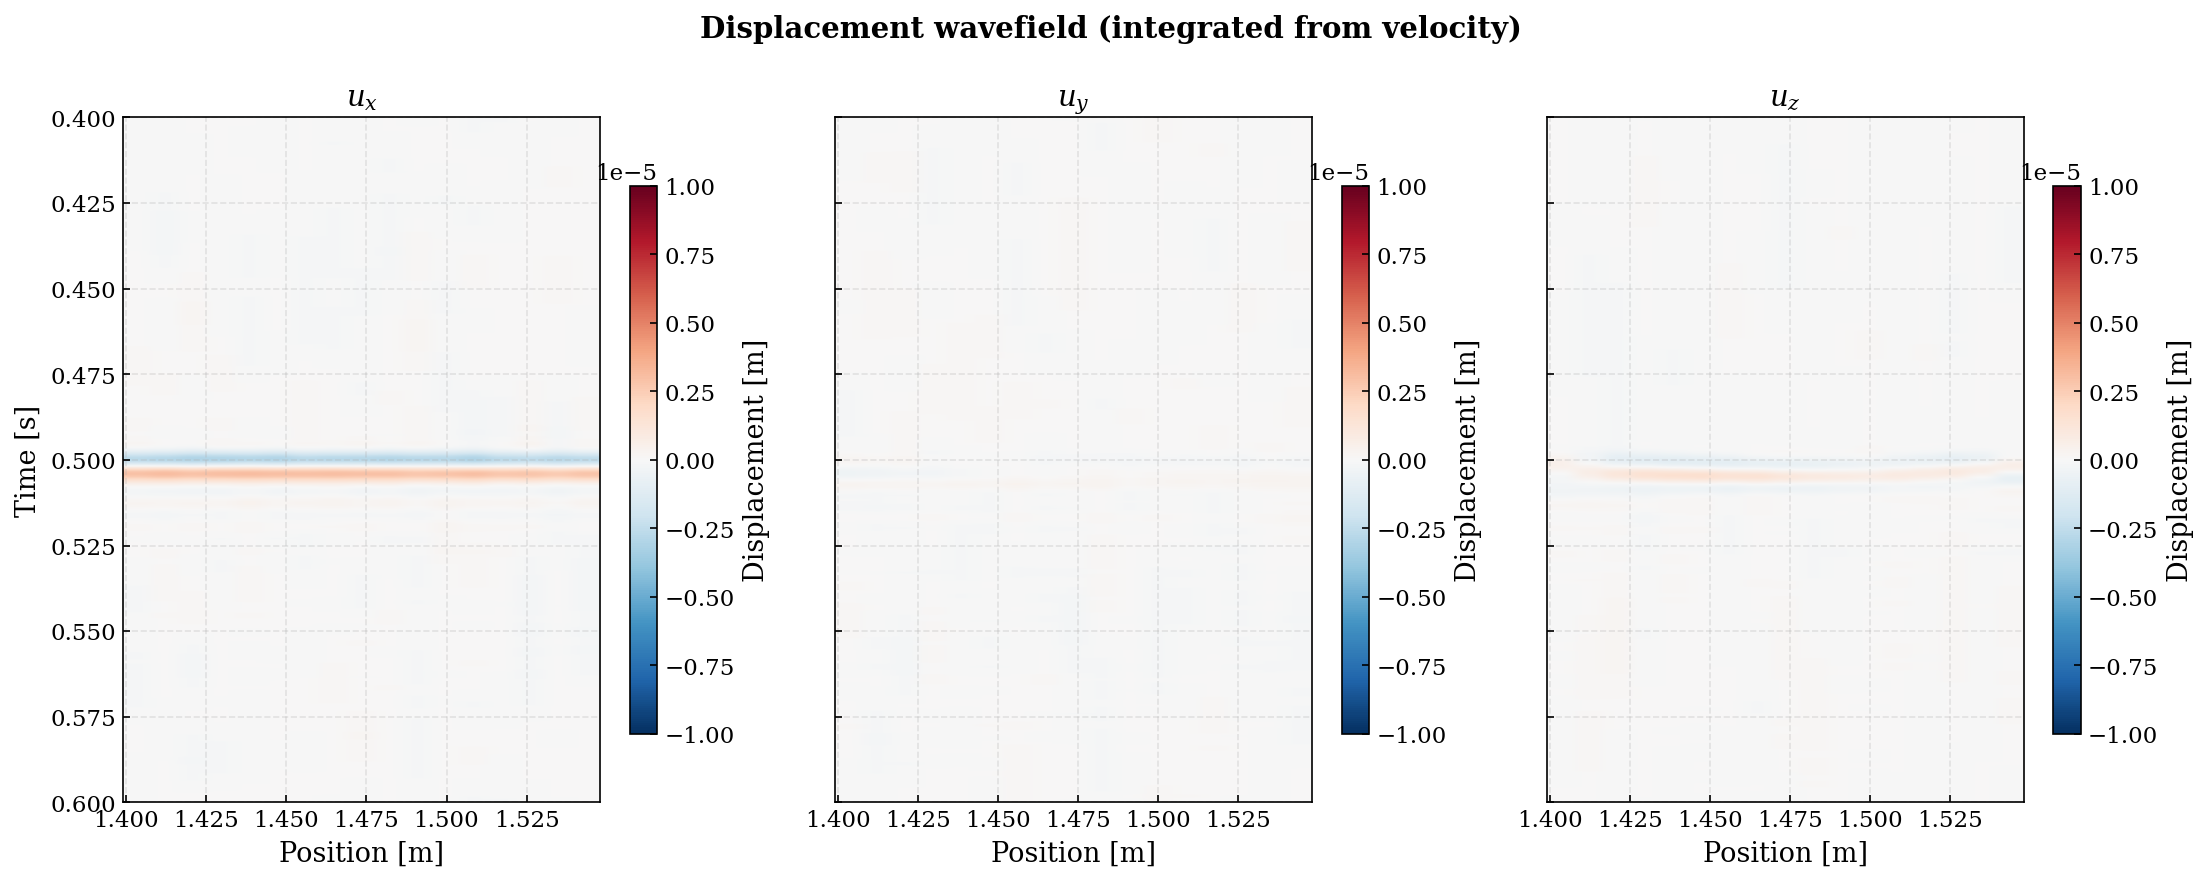

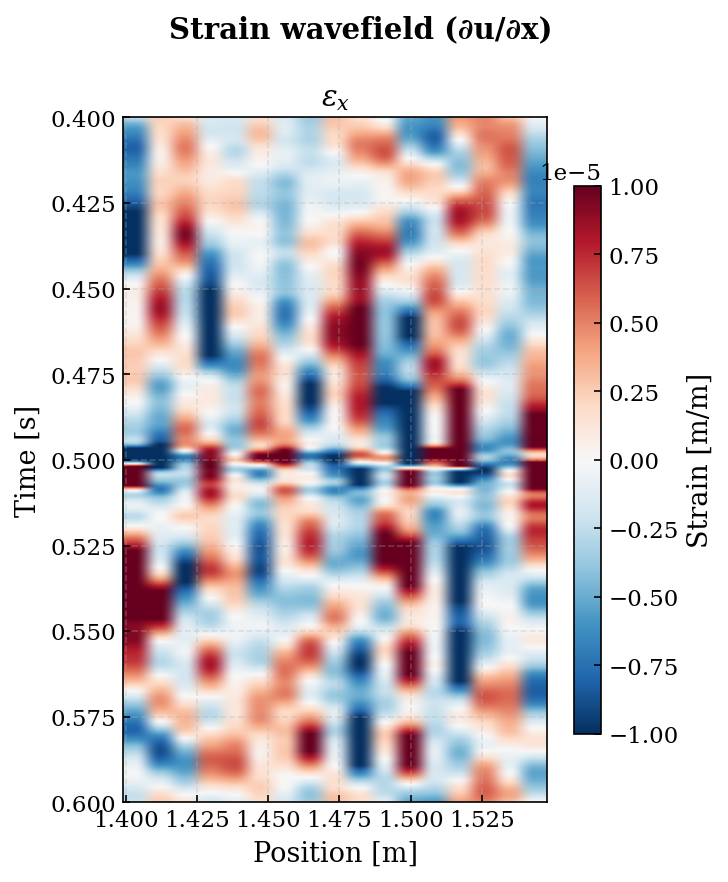

In [48]:
def velocity_to_displacement(
    vel: np.ndarray,
    dt: float,
    method: str = "freq",
    fmin: float = 3.0,
) -> np.ndarray:
    """Integrate velocity to displacement along axis 0 (time).

    Parameters
    ----------
    vel : 2-D array (N_samples × N_sensors) [m/s]
    dt  : time step [s]
    method : "freq" (recommended) or "trapz"
        - "freq": frequency-domain integration with low-frequency regularization
        - "trapz": cumulative trapezoidal integration
    fmin : float
        Minimum frequency [Hz] used in "freq" mode to avoid low-frequency noise blow-up.

    Returns
    -------
    disp : 2-D array (N_samples × N_sensors) [m]
    """
    v = vel # detrend(vel, axis=0, type="linear") # optional detrending to remove linear drift before integration

    if method == "trapz":
        return cumulative_trapezoid(v, dx=dt, axis=0, initial=0)

    if method == "freq":
        n = v.shape[0]
        freqs = np.fft.rfftfreq(n, d=dt)
        omega = 2 * np.pi  * np.maximum(freqs, fmin)  # regularized denominator

        V = np.fft.rfft(v, axis=0)
        U = V / (1j * omega[:, None])
        U[0, :] = 0.0  # enforce zero-mean displacement

        u = np.fft.irfft(U, n=n, axis=0)
        return detrend(u, axis=0, type="constant")  # remove residual offset

    raise ValueError("method must be 'freq' or 'trapz'")


def spatial_gradient(
    field: np.ndarray,
    x: np.ndarray,
    method: str = "wavenumber",
    use_mean_dx: bool = True,
    k_cutoff_fraction: float = 0.71,
) -> np.ndarray:
    """Compute spatial gradient ∂field/∂x along axis 1 (space).

    Parameters
    ----------
    field : 2-D array (N_samples × N_sensors)
    x     : sensor positions (N_sensors,) [m]
    method : "finite" or "wavenumber"
        - "finite": np.gradient with non-uniform spacing (2nd-order interior)
        - "wavenumber": spectral derivative in k-domain (assumes ~uniform spacing)
    use_mean_dx : bool
        If True, use mean spacing for "wavenumber" even when x is slightly non-uniform.
        If False, raise an error when spacing is non-uniform.
    k_cutoff_fraction : float
        Fraction of the maximum wavenumber to use as a cutoff in "wavenumber" mode.

    Returns
    -------
    grad : 2-D array (N_samples × N_sensors)
    """
    if method == "finite":
        return np.gradient(field, x, axis=1, edge_order=2)

    if method == "wavenumber":
        dx_all = np.diff(x)
        dx_mean = dx_all.mean()
        print(f"Mean dx: {dx_mean:.6f} m; Max deviation: {np.abs(dx_all - dx_mean).max():.2e} m")

        # FFT along the spatial axis
        F = np.fft.fft(field, axis=1)
        k = np.fft.fftfreq(field.shape[1], d=dx_mean)
        
        # 1. Create a Wavenumber Taper (Low-pass filter)
        # We suppress the highest wavenumbers to kill the alternating Nyquist striping
        k_max = np.max(np.abs(k))
        k_cutoff = k_cutoff_fraction * k_max
        
        # A smooth exponential (Butterworth-like) roll-off taper
        # You can adjust the power (4) to make the cutoff steeper or gentler
        taper = np.exp(- (np.abs(k) / k_cutoff)**4) 
        
        # 2. Apply derivative operator AND the taper
        ik = 1j * 2 * np.pi * k
        grad = np.fft.ifft(ik[None, :] * taper[None, :] * F, axis=1).real
        
        return grad

    raise ValueError("method must be 'finite' or 'wavenumber'")


dt = t[1] - t[0]   # time step [s]

# ── Displacement by integration of velocity (time axis) ──────────────────
ux = velocity_to_displacement(vx, dt)   # (N_samples × N_sensors)  [m]
uy = velocity_to_displacement(vy, dt)
uz = velocity_to_displacement(vz, dt)

# ── Strain: spatial gradient of displacement ──────────────────────────────
strain_x = spatial_gradient(ux, x_raw)     # ε_x = ∂u_x/∂x
#strain_y = spatial_gradient(uy, x_raw)     # ε_y = ∂u_y/∂x
#strain_z = spatial_gradient(uz, x_raw)     # ε_z = ∂u_z/∂x  (bending strain proxy)

# look only at every second sensor to avoid edge artifacts in gradient
#ux = ux[:, ::2]
#strain_x = strain_x[:, ::2]
#strain_y = strain_y[:, ::2]
#strain_z = strain_z[:, ::2]

# normalize amplitudes 
#ux /= np.abs(ux).max()
#strain_x /= np.abs(strain_x).max()


print("Displacement and strain computed.")
print(f"  Peak |ε_x|: {np.abs(strain_x).max():.3e} m/m")

# ── Plot displacement wavefields ──────────────────────────────────────────
plot_wavefield(
    x_raw, t,
    components={"$u_x$": ux, "$u_y$": uy, "$u_z$": uz},
    clim=1e-5,
    t_min=T_MIN, t_max=T_MAX,
    #t_min=4.00, t_max=4.020,
    label_unit="Displacement [m]",
    suptitle="Displacement wavefield (integrated from velocity)",
)

# ── Plot strain wavefields ────────────────────────────────────────────────
plot_wavefield(
    x_raw, t,
    components={"$\\varepsilon_x$": strain_x}, # "$\\varepsilon_y$": strain_y, "$\\varepsilon_z$": strain_z},
    clim=0.1 * 1e-4,
    #clim=1e-6,
    t_min=T_MIN, t_max=T_MAX,
    #t_min=4.00, t_max=4.020,
    label_unit="Strain [m/m]",
    suptitle="Strain wavefield (∂u/∂x)",
)

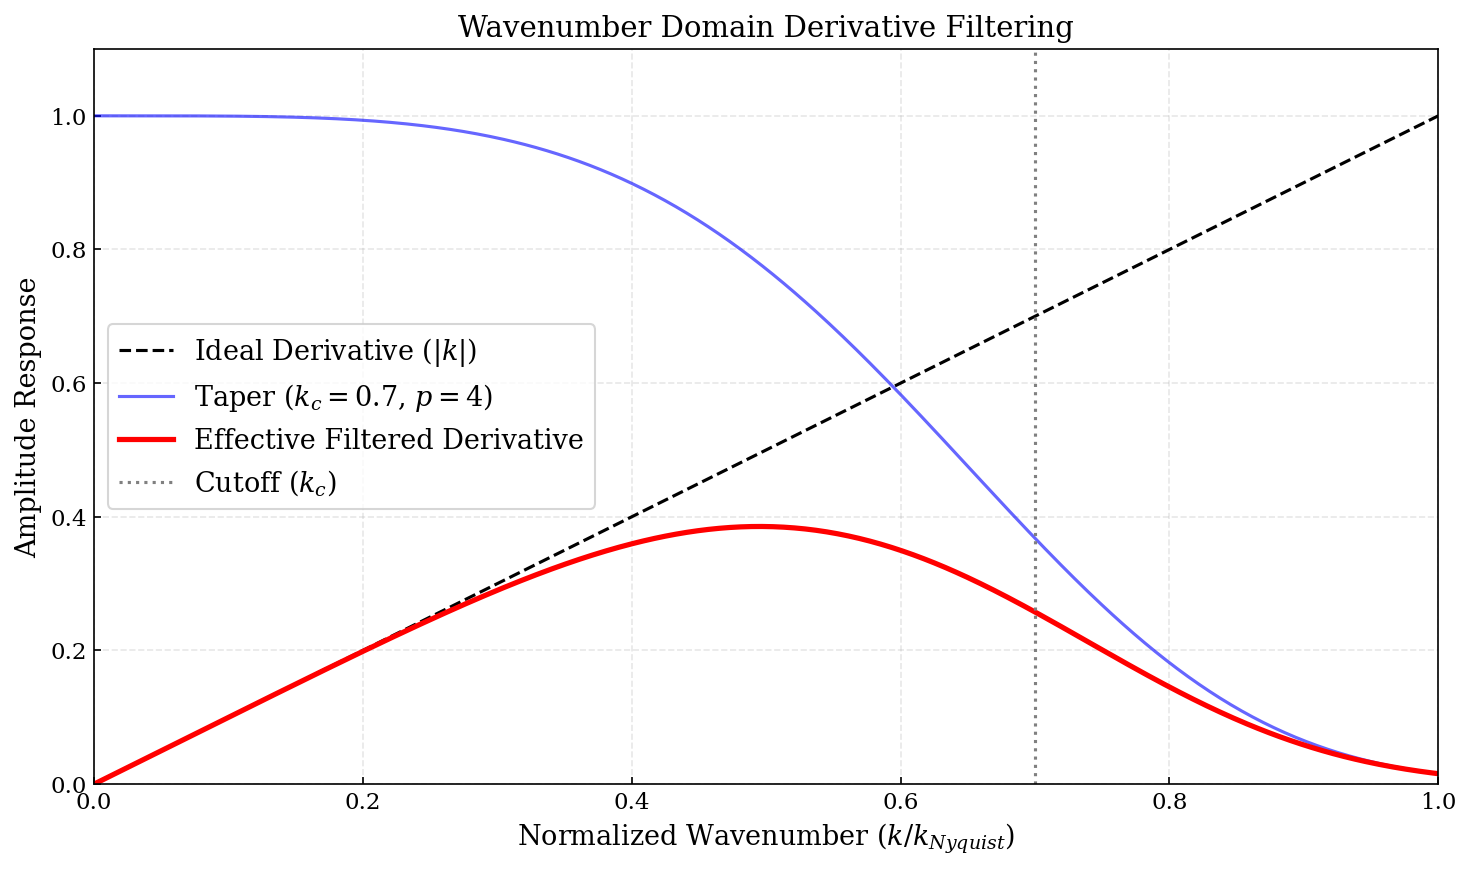

In [186]:
import numpy as np
import matplotlib.pyplot as plt

def plot_derivative_taper(k_cutoff_fraction=0.7, power=4):
    # Create normalized wavenumbers from 0 to Nyquist (1.0)
    k = np.linspace(0, 1.0, 500)
    
    # 1. Ideal Derivative Amplitude (|i * 2 * pi * k|)
    # (We drop the 2*pi constant for easier visualization normalization)
    ideal_derivative = k 
    
    # 2. Taper (Low-pass filter)
    k_c = k_cutoff_fraction
    taper = np.exp(-(k / k_c)**power)
    
    # 3. Effective Derivative Filter
    effective_filter = ideal_derivative * taper
    
    # Plotting
    plt.figure(figsize=(10, 6))
    
    plt.plot(k, ideal_derivative, 'k--', label='Ideal Derivative ($|k|$)')
    plt.plot(k, taper, 'b-', alpha=0.6, label=f'Taper ($k_c={k_cutoff_fraction}$, $p={power}$)')
    plt.plot(k, effective_filter, 'r-', linewidth=2.5, label='Effective Filtered Derivative')
    
    # Formatting
    plt.axvline(k_cutoff_fraction, color='gray', linestyle=':', label='Cutoff ($k_c$)')
    plt.title('Wavenumber Domain Derivative Filtering')
    plt.xlabel('Normalized Wavenumber ($k / k_{Nyquist}$)')
    plt.ylabel('Amplitude Response')
    plt.xlim(0, 1)
    plt.ylim(0, 1.1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run the function to see the plot
plot_derivative_taper(k_cutoff_fraction=0.7, power=4)

Displacement and strain computed.
  Peak |ε_x|: 1.220e-05 m/m


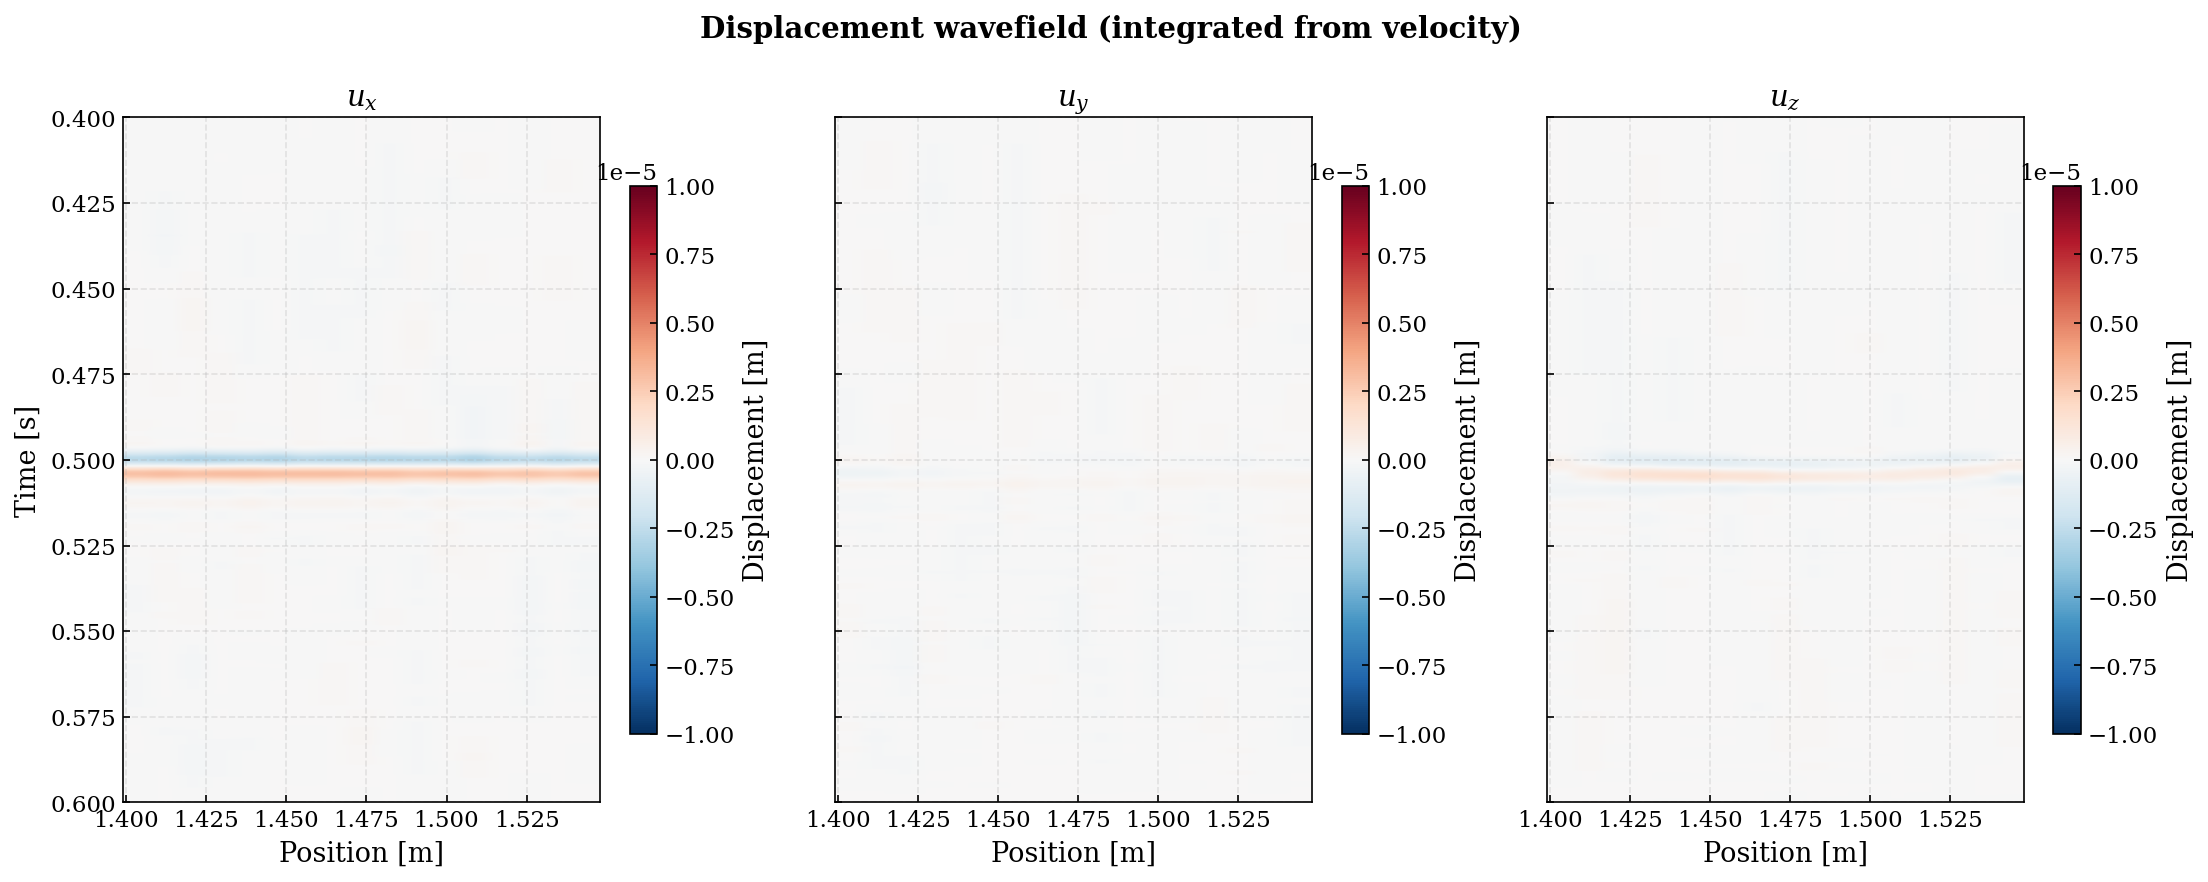

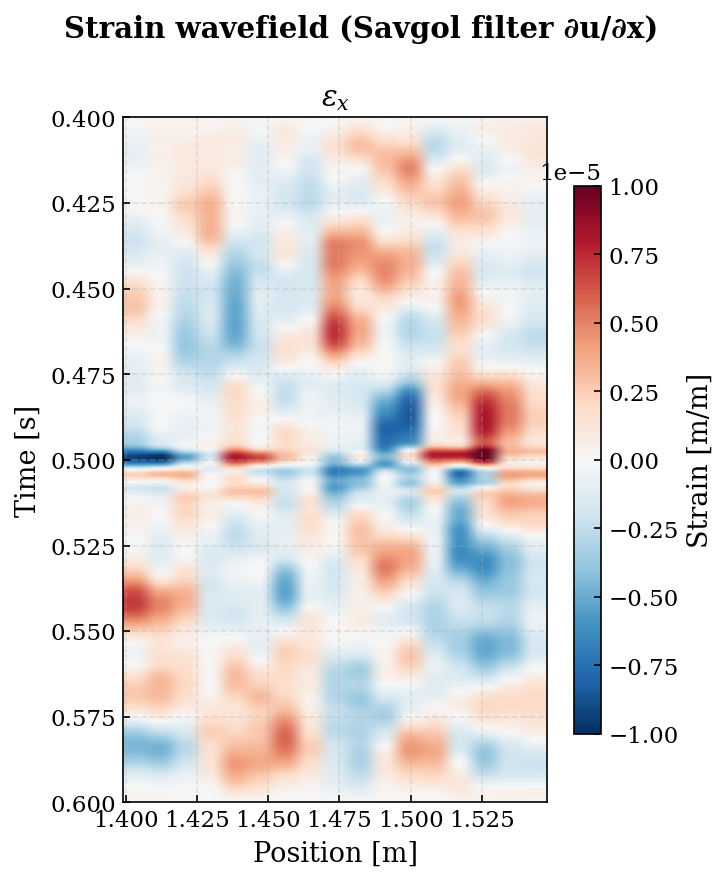

In [53]:
import numpy as np
from scipy.signal import detrend, savgol_filter
from scipy.integrate import cumulative_trapezoid

def velocity_to_displacement(
    vel: np.ndarray,
    dt: float,
    method: str = "freq",
    fmin: float = 1.0,
) -> np.ndarray:
    """Integrate velocity to displacement along axis 0 (time).

    Parameters
    ----------
    vel : 2-D array (N_samples × N_sensors) [m/s]
    dt  : time step [s]
    method : "freq" (recommended) or "trapz"
        - "freq": frequency-domain integration with low-frequency regularization
        - "trapz": cumulative trapezoidal integration
    fmin : float
        Minimum frequency [Hz] used in "freq" mode to avoid low-frequency noise blow-up.

    Returns
    -------
    disp : 2-D array (N_samples × N_sensors) [m]
    """
    v = detrend(vel, axis=0, type="linear")

    if method == "trapz":
        return cumulative_trapezoid(v, dx=dt, axis=0, initial=0)

    if method == "freq":
        n = v.shape[0]
        freqs = np.fft.rfftfreq(n, d=dt)
        omega = 2 * np.pi * np.maximum(freqs, fmin)  # regularized denominator

        V = np.fft.rfft(v, axis=0)
        U = V / (1j * omega[:, None])
        U[0, :] = 0.0  # enforce zero-mean displacement

        u = np.fft.irfft(U, n=n, axis=0)
        return detrend(u, axis=0, type="constant")  # remove residual offset

    raise ValueError("method must be 'freq' or 'trapz'")


def spatial_gradient(
    field: np.ndarray,
    x: np.ndarray,
    method: str = "finite",
    use_mean_dx: bool = True,
    rtol_dx: float = 5e-3,
    savgol_window: int = 5,
    savgol_poly: int = 2,
) -> np.ndarray:
    """Compute spatial gradient ∂field/∂x along axis 1 (space).

    Parameters
    ----------
    field : 2-D array (N_samples × N_sensors)
    x     : sensor positions (N_sensors,) [m]
    method : "finite", "wavenumber", or "savgol"
        - "finite": np.gradient with non-uniform spacing (2nd-order interior)
        - "wavenumber": spectral derivative in k-domain (assumes ~uniform spacing)
        - "savgol": Savitzky-Golay filter (smooths and differentiates simultaneously)
    use_mean_dx : bool
        If True, use mean spacing for "wavenumber"/"savgol" even when x is slightly non-uniform.
    rtol_dx : float
        Relative tolerance for spacing non-uniformity check.
    savgol_window : int
        The length of the filter window (number of sensors). Must be an odd integer.
    savgol_poly: int
        The order of the polynomial used to fit the samples. Must be less than window length.

    Returns
    -------
    grad : 2-D array (N_samples × N_sensors)
    """
    if method == "finite":
        return np.gradient(field, x, axis=1, edge_order=2)
        
    if method == "savgol":
        dx_mean = np.diff(x).mean()
        # Ensure the window length is odd
        if savgol_window % 2 == 0:
            savgol_window += 1
            print(f"Warning: savgol_window must be odd. Adjusting to {savgol_window}.")
            
        # savgol_filter applies smoothing and the derivative (deriv=1) across the spatial axis (axis=1)
        return savgol_filter(
            field, 
            window_length=savgol_window, 
            polyorder=savgol_poly, 
            deriv=1, 
            delta=dx_mean, 
            axis=1, 
            mode="nearest"
        )

    if method == "wavenumber":
        dx_all = np.diff(x)
        dx_mean = dx_all.mean()
        nonuniform = np.any(np.abs(dx_all - dx_mean) > rtol_dx * dx_mean)

        if nonuniform and not use_mean_dx:
            raise ValueError(
                "x is non-uniform; wavenumber method requires uniform spacing "
                "(or set use_mean_dx=True)."
            )
        if nonuniform and use_mean_dx:
            print("Warning: x is non-uniform; using mean dx for wavenumber gradient.")

        F = np.fft.fft(field, axis=1)  # along sensors
        k = np.fft.fftfreq(field.shape[1], d=dx_mean)  # cycles/m
        grad = np.fft.ifft((1j * 2 * np.pi * k)[None, :] * F, axis=1).real
        return grad

    raise ValueError("method must be 'finite', 'wavenumber', or 'savgol'")


dt = t[1] - t[0]   # time step [s]

# ── Displacement by integration of velocity (time axis) ──────────────────
ux = velocity_to_displacement(vx, dt)   # (N_samples × N_sensors)  [m]
uy = velocity_to_displacement(vy, dt)
uz = velocity_to_displacement(vz, dt)

# ── Strain: spatial gradient of displacement ──────────────────────────────
# Using the newly implemented Savitzky-Golay method
strain_x = spatial_gradient(
    ux, 
    x_raw, 
    method="savgol", 
    savgol_window=5, # Play with this: 5, 7, 9, 11 (must be odd)
    savgol_poly=2    # Quadratic fit is usually safe
)

#strain_y = spatial_gradient(uy, x_raw, method="savgol")
#strain_z = spatial_gradient(uz, x_raw, method="savgol")

print("Displacement and strain computed.")
print(f"  Peak |ε_x|: {np.abs(strain_x).max():.3e} m/m")

# ── Plot displacement wavefields ──────────────────────────────────────────
plot_wavefield(
    x_raw, t,
    components={"$u_x$": ux, "$u_y$": uy, "$u_z$": uz},
    clim=1e-5,
    t_min=T_MIN, t_max=T_MAX,
    #t_min=0.0, t_max=0.42,
    label_unit="Displacement [m]",
    suptitle="Displacement wavefield (integrated from velocity)",
)

# ── Plot strain wavefields ────────────────────────────────────────────────
plot_wavefield(
    x_raw, t,
    components={"$\\varepsilon_x$": strain_x},
    clim=1e-5,
    #clim=1e-6,
    t_min=T_MIN, t_max=T_MAX,
    #t_min=5.2090, t_max=5.3000,
    label_unit="Strain [m/m]",
    suptitle=f"Strain wavefield (Savgol filter ∂u/∂x)",
)

In [187]:
np.shape(vx)

(50000, 39)

---
## Section 7 — Strain Rate

**Strain rate** $\dot{\varepsilon}$ is the time derivative of strain, or equivalently the **spatial gradient of velocity**:

$$\dot{\varepsilon}(x, t) = \frac{\partial \varepsilon}{\partial t} = \frac{\partial}{\partial t}\frac{\partial u}{\partial x} = \frac{\partial v}{\partial x}$$

The second identity $\dot\varepsilon = \partial v / \partial x$ is kinematically exact (space and time derivatives commute) and is numerically preferable because it avoids the integration step — therefore **reducing accumulation of numerical error**.

Both routes are computed below for verification; they should be nearly identical.

Mean dx: 0.013437 m; Max deviation: 2.48e-04 m
Max |∂ε_x/∂t − ∂v_x/∂x| = 5.016e-03 s⁻¹  (should be small)


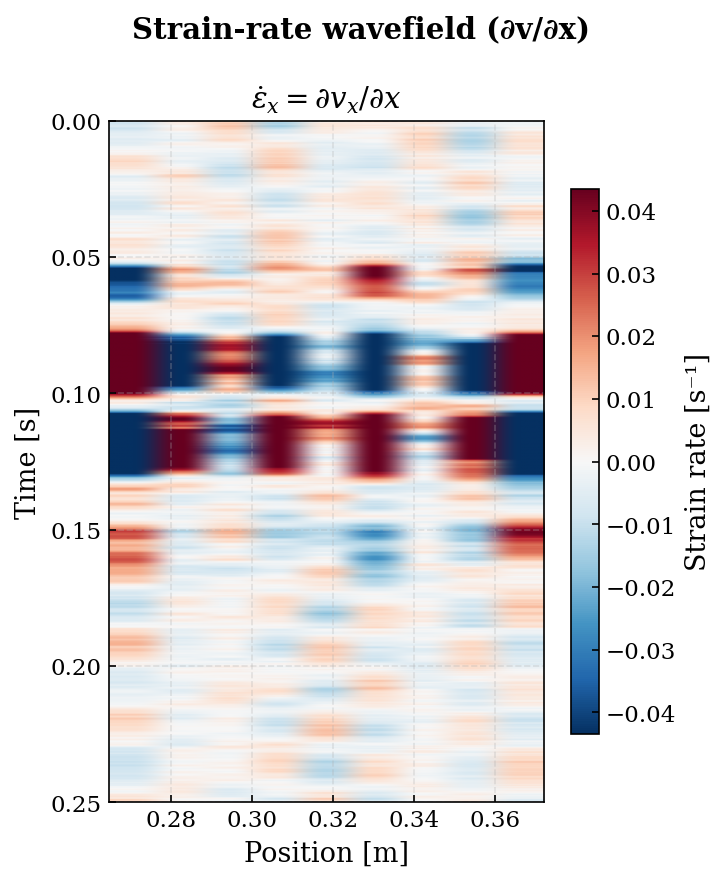

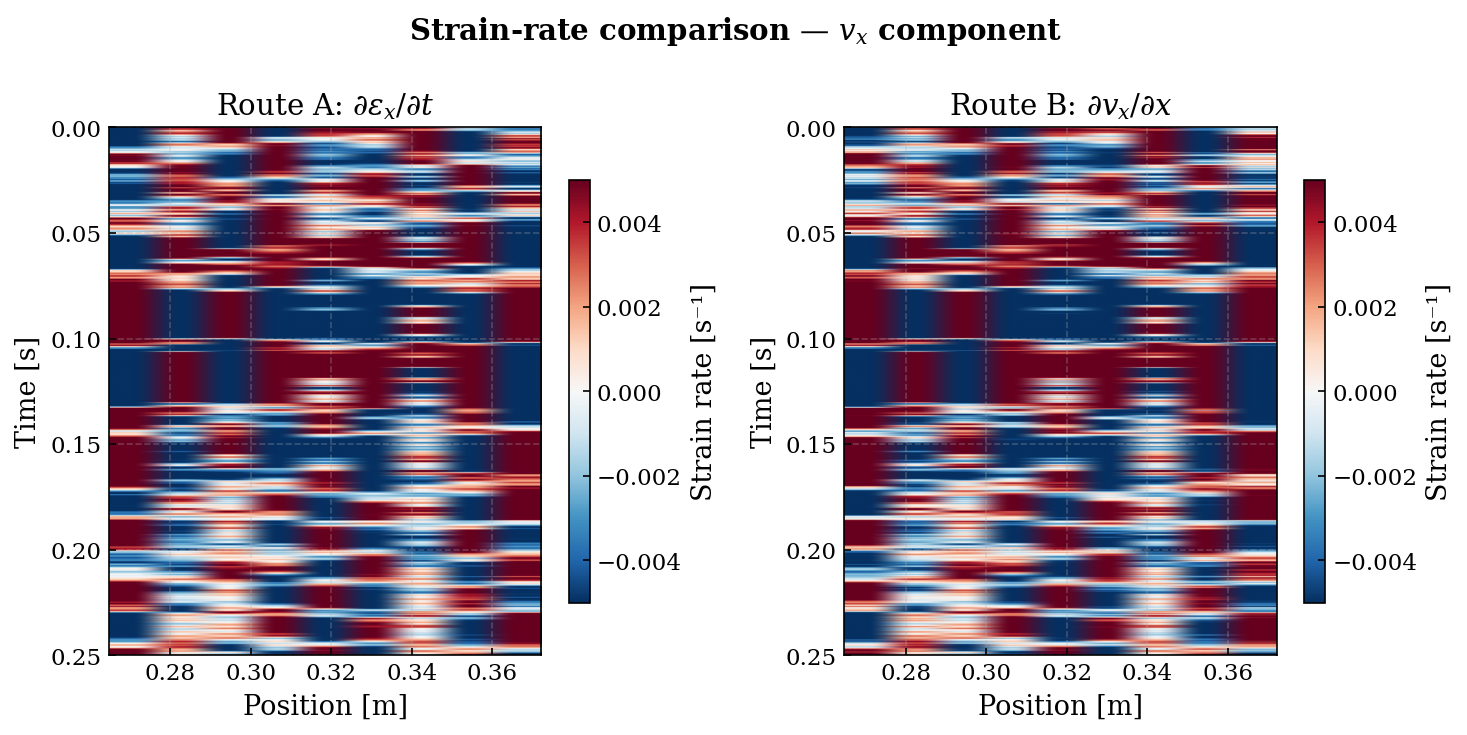

In [18]:
def time_derivative(field: np.ndarray, dt: float) -> np.ndarray:
    """Compute dy/dt along axis 0 using numpy.gradient (2nd-order central differences).

    Parameters
    ----------
    field : 2-D array (N_samples × N_sensors)
    dt    : time step [s]

    Returns
    -------
    dfdt : 2-D array, same shape
    """
    return np.gradient(field, dt, axis=0)


# ── Route A: ∂ε/∂t  (time-derivative of strain) ──────────────────────────
strain_rate_from_strain_x = time_derivative(strain_x, dt)
#strain_rate_from_strain_y = time_derivative(strain_y, dt)
#strain_rate_from_strain_z = time_derivative(strain_z, dt)

# ── Route B: ∂v/∂x  (spatial gradient of velocity)  — preferred ──────────
strain_rate_x = spatial_gradient(vx, x_raw)
#strain_rate_y = spatial_gradient(vy, x_raw)
#strain_rate_z = spatial_gradient(vz, x_raw)

# ── Quick consistency check ───────────────────────────────────────────────
residual = np.abs(strain_rate_x - strain_rate_from_strain_x).max()
print(f"Max |∂ε_x/∂t − ∂v_x/∂x| = {residual:.3e} s⁻¹  (should be small)")

# ── Plot strain-rate wavefields (Route B — direct spatial gradient of v) ──
plot_wavefield(
    x_raw, t,
    components={
        "$\\dot{\\varepsilon}_x = \\partial v_x/\\partial x$": strain_rate_x,
        #"$\\dot{\\varepsilon}_y = \\partial v_y/\\partial x$": strain_rate_y,
        #"$\\dot{\\varepsilon}_z = \\partial v_z/\\partial x$": strain_rate_z,
    },
    clim=0.2 * np.abs(strain_rate_x).max(),
    t_min=T_MIN, t_max=T_MAX,
    #t_min=2.08, t_max=2.18,
    label_unit="Strain rate [s⁻¹]",
    suptitle="Strain-rate wavefield (∂v/∂x)",
)

# ── Side-by-side comparison for v_z (the dominant component) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

#clim = 0.025 * np.abs(strain_rate_x).max()

clim = 0.05 * 1e-1
for ax, data, title in zip(
    axes,
    [strain_rate_from_strain_x, strain_rate_x],
    ["Route A: $\\partial\\varepsilon_x/\\partial t$",
     "Route B: $\\partial v_x / \\partial x$"],
):
    im = ax.imshow(
        data,
        aspect="auto",
        origin="upper",
        extent=[x_raw[0], x_raw[-1], t[-1], t[0]],
        vmin=-clim, vmax=clim,
    )
    ax.set_ylim(T_MAX, T_MIN)
    #ax.set_ylim(1.2090, 1.3000)
    ax.set_xlabel("Position [m]")
    ax.set_ylabel("Time [s]")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="Strain rate [s⁻¹]", shrink=0.8)

fig.suptitle("Strain-rate comparison — $v_x$ component", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

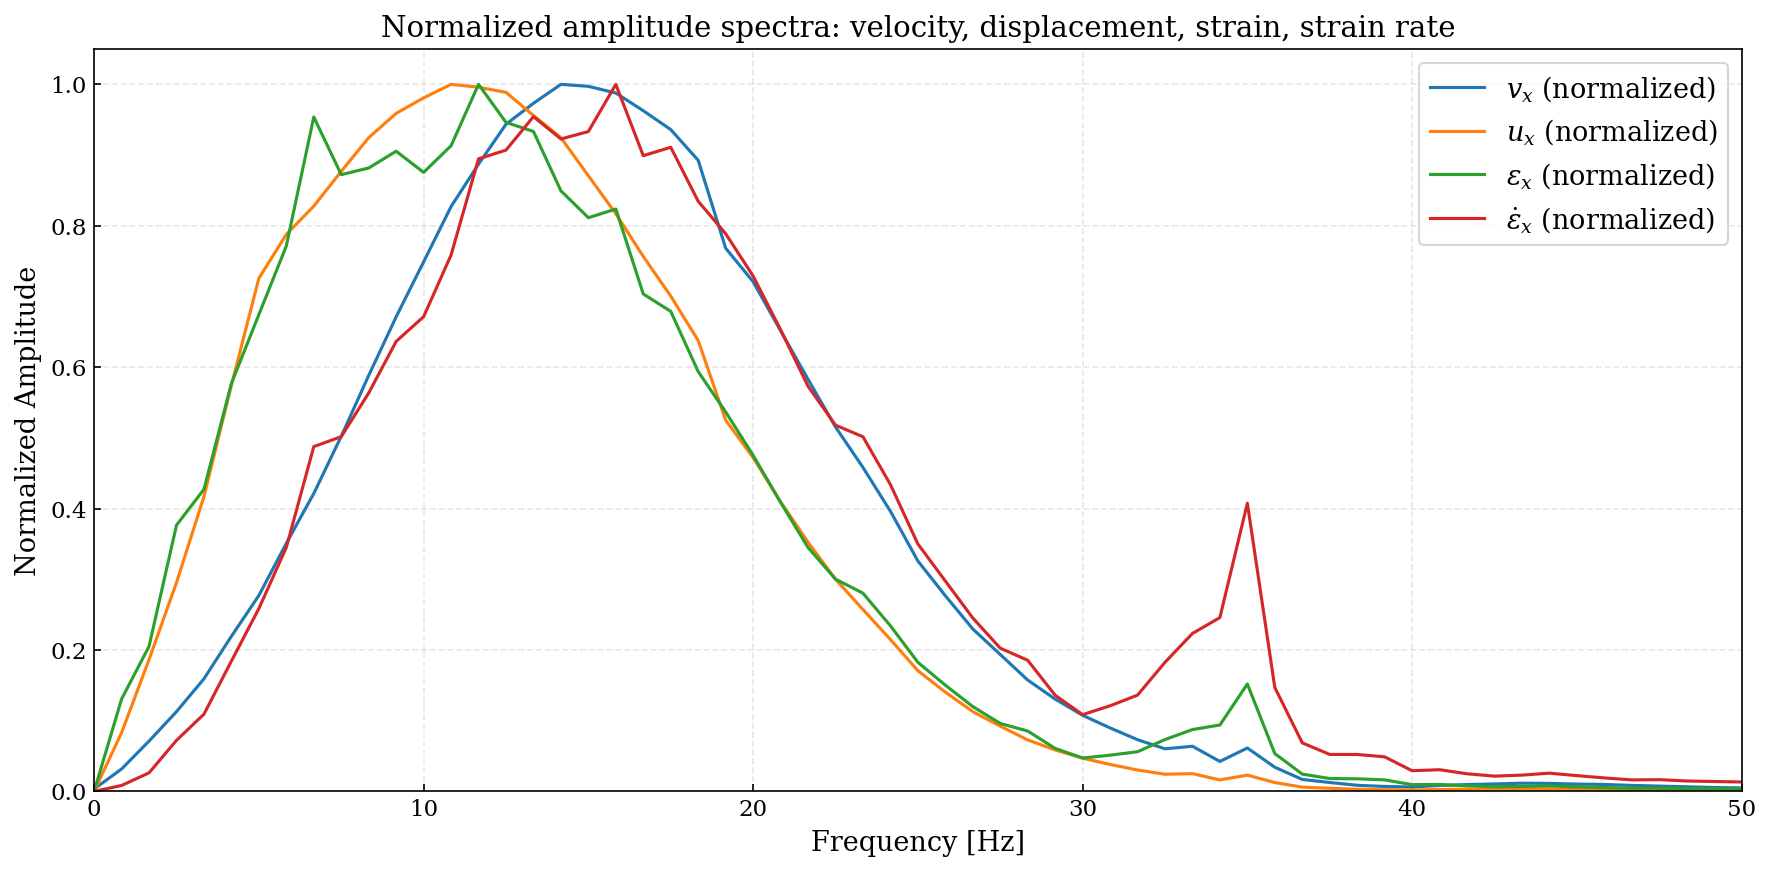

In [41]:
# Amplitude spectra
freqs, amp_vx = mean_amplitude_spectrum(vx, fs)
_, amps_strain = mean_amplitude_spectrum(strain_x, fs)
_, amps_strain_rate = mean_amplitude_spectrum(strain_rate_from_strain_x, fs)
_, amps_disp = mean_amplitude_spectrum(ux, fs)

# Normalize each curve by its own peak (same style as your previous example)
eps = 1e-12
amp_vx_n = amp_vx / (np.max(amp_vx) + eps)
amps_strain_n = amps_strain / (np.max(amps_strain) + eps)
amps_strain_rate_n = amps_strain_rate / (np.max(amps_strain_rate) + eps)
amps_disp_n = amps_disp / (np.max(amps_disp) +eps)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(freqs, amp_vx_n, lw=1.5, label=r"$v_x$ (normalized)")
ax.plot(freqs, amps_disp_n, lw=1.5, label=r"$u_x$ (normalized)")
ax.plot(freqs, amps_strain_n, lw=1.5, label=r"$\varepsilon_x$ (normalized)")
ax.plot(freqs, amps_strain_rate_n, lw=1.5, label=r"$\dot{\varepsilon}_x$ (normalized)")

ax.set_xlim(0, min(fs / 2, 50))
ax.set_ylim(0, 1.05)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Normalized Amplitude")
ax.set_title("Normalized amplitude spectra: velocity, displacement, strain, strain rate")
ax.grid(True, ls="--", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

---
## Summary of reusable functions

| Function | Where defined | Purpose |
|---|---|---|
| `bandpass_filtfilt` | Section 2 | Zero-phase Butterworth bandpass along time axis |
| `plot_wavefield` | Section 3 | Space–time image of any wavefield matrix |
| `mean_amplitude_spectrum` | Section 4 | Single-sided FFT amplitude, averaged over sensors |
| `fk_spectrum` | Section 5 | 2-D FK transform, returned in dB |
| `velocity_to_displacement` | Section 6 | Cumulative trapezoidal time integration |
| `spatial_gradient` | Section 6 | `np.gradient` along sensor array (handles irregular spacing) |
| `time_derivative` | Section 7 | `np.gradient` along time axis |

All functions accept `(N_samples × N_sensors)` arrays with time on `axis=0` and space on `axis=1`.

## NEW STUFF !!!

In [5]:
import numpy as np
from scipy.ndimage import gaussian_filter

def integrate_time_fft(vel: np.ndarray, dt: float, fmin: float = 10.0) -> np.ndarray:
    """Integrates velocity to displacement using FFT (U = V / iω)."""
    n = vel.shape[0]
    freqs = np.fft.rfftfreq(n, d=dt)
    
    # Hard clamp to prevent divide-by-zero at DC
    omega = 2 * np.pi * np.maximum(freqs, fmin) 
    
    V = np.fft.rfft(vel, axis=0)
    U = V / (1j * omega[:, None])
    U[0, :] = 0.0 # Enforce zero-mean 
    return np.fft.irfft(U, n=n, axis=0)

def spatial_gradient_fft(field: np.ndarray, dx: float, k_cutoff: float | None = None) -> np.ndarray:
    """
    Computes spatial derivative ∂/∂x using FFT.
    If k_cutoff is provided (e.g., 0.5), applies a high-k taper (useful for short arrays).
    """
    nx = field.shape[1]
    k = np.fft.fftfreq(nx, d=dx)
    
    F = np.fft.fft(field, axis=1)
    ik = 1j * 2 * np.pi * k
    
    if k_cutoff is not None:
        k_max = np.max(np.abs(k))
        # Smooth exponential roll-off
        taper = np.exp(- (np.abs(k) / (k_cutoff * k_max))**4)
        grad_F = ik[None, :] * taper[None, :] * F
    else:
        grad_F = ik[None, :] * F
        
    return np.fft.ifft(grad_F, axis=1).real

In [9]:
def fk_fan_filter(
    data: np.ndarray, 
    dt: float, 
    dx: float, 
    v_min: float, 
    v_max: float, 
    pad_factor: int = 2,
    f_preserve: float = 0.5
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Applies a velocity fan filter with zero-padding for high resolution.
    Returns: filtered_data, f_axis (padded), k_axis (padded), spec_db (padded)
    """
    nt, nx = data.shape
    nt_pad, nx_pad = nt * pad_factor, nx * pad_factor
    
    # 2D FFT with zero padding for higher visual resolution
    F2D = np.fft.fft2(data, s=(nt_pad, nx_pad))
    
    f = np.fft.fftfreq(nt_pad, d=dt)
    k = np.fft.fftfreq(nx_pad, d=dx)
    K_grid, F_grid = np.meshgrid(k, f)
    
    # Calculate apparent velocity safely
    with np.errstate(divide='ignore', invalid='ignore'):
        v_app = np.abs(F_grid / K_grid)
        v_app[K_grid == 0] = np.inf
        
    # Velocity mask + low frequency preservation
    mask = (v_app >= v_min) & (v_app <= v_max)
    mask = mask | (np.abs(F_grid) < f_preserve) # Protect low frequencies!
    
    # Taper the mask to prevent ringing
    smooth_mask = gaussian_filter(mask.astype(float), sigma=2.0)
    
    # Apply mask and inverse FFT
    F2D_filtered = F2D * smooth_mask
    filtered_data_padded = np.fft.ifft2(F2D_filtered).real
    
    # Slice off the padding to return the original physical dimensions
    filtered_data = filtered_data_padded[:nt, :nx]
    
    # Compute robust dB spectrum
    F2D_shifted = np.fft.fftshift(F2D_filtered)
    f_shifted = np.fft.fftshift(f)
    k_shifted = np.fft.fftshift(k)
    
    f_max_val = np.abs(F2D_shifted).max()
    if f_max_val == 0: f_max_val = 1e-12 # Prevent RuntimeWarning
    
    spec_db = 20 * np.log10((np.abs(F2D_shifted) + 1e-12) / f_max_val)
    spec_db = np.clip(spec_db, -40, 0)
    
    return filtered_data, f_shifted, k_shifted, spec_db

In [10]:
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def interactive_wavefield_analysis(vx: np.ndarray, t: np.ndarray, x: np.ndarray):
    dt = t[1] - t[0]
    dx = np.diff(x).mean()
    
    # --- UI CONTROLS ---
    # Top Row
    qty_dd = widgets.Dropdown(options=["Velocity", "Displacement", "Strain"], value="Velocity", description="View Qty:")
    stage_dd = widgets.Dropdown(options=["None", "Velocity", "Displacement", "Strain"], value="None", description="Apply F-K To:")
    t_range = widgets.FloatRangeSlider(value=[t.min(), t.max()], min=t.min(), max=t.max(), step=dt*10, description='Time [s]', layout={'width': '400px'})
    
    # Middle Row (F-K Params)
    vmin_sld = widgets.IntSlider(value=800, min=100, max=2500, step=50, description='v_min [m/s]')
    vmax_sld = widgets.IntSlider(value=1300, min=100, max=3000, step=50, description='v_max [m/s]')
    pad_dd = widgets.Dropdown(options=[1, 2, 4], value=2, description="F-K Padding:")
    
    # Bottom Row (Integration & Scale)
    fmin_sld = widgets.FloatLogSlider(value=10.0, base=10, min=0, max=3, step=0.1, description='Int. f_min [Hz]')
    kcut_cb = widgets.Checkbox(value=False, description='Apply k_cutoff (0.5)')
    clim_sld = widgets.FloatLogSlider(value=1.0, base=10, min=-2, max=0, step=0.1, description='Clim Factor')
    
    out = widgets.Output()
    
    def update_plot(qty, filter_stage, t_bounds, v_min, v_max, f_min, apply_kcut, clim_factor, pad):
        with out:
            out.clear_output(wait=True)
            k_cut_val = 0.5 if apply_kcut else None
            
            # --- 1. Compute Pipeline based on Stage ---
            data_dict = {}
            
            # Base variables
            current_vx = vx.copy()
            
            if filter_stage == "Velocity":
                current_vx, f_ax, k_ax, fk_filt = fk_fan_filter(current_vx, dt, dx, v_min, v_max, pad)
            else:
                _, f_ax, k_ax, fk_filt = fk_fan_filter(np.zeros_like(vx), dt, dx, v_min, v_max, pad) # Dummy
                
            disp = integrate_time_fft(current_vx, dt, fmin=f_min)
            
            if filter_stage == "Displacement":
                disp, f_ax, k_ax, fk_filt = fk_fan_filter(disp, dt, dx, v_min, v_max, pad)
                
            strain = spatial_gradient_fft(disp, dx, k_cutoff=k_cut_val)
            
            if filter_stage == "Strain":
                strain, f_ax, k_ax, fk_filt = fk_fan_filter(strain, dt, dx, v_min, v_max, pad)
            
            # Compute Unfiltered F-K of the target quantity for comparison
            target_data = {"Velocity": current_vx, "Displacement": disp, "Strain": strain}[qty]
            _, _, _, fk_raw = fk_fan_filter(target_data, dt, dx, 0, np.inf, pad) # All velocities allowed
            
            # --- 2. Build Plotly Grid ---
            fig = make_subplots(
                rows=2, cols=2, 
                subplot_titles=(f"{qty} Wavefield", "Filtered Wavefield (If Active)", f"{qty} Raw F-K", "Filtered F-K"),
                vertical_spacing=0.15, horizontal_spacing=0.05
            )
            
            # Dynamic Clim
            base_clim = np.abs(target_data).max() * clim_factor
            
            # Space-Time Plots
            fig.add_trace(go.Heatmap(z=target_data, x=x, y=t, zmin=-base_clim, zmax=base_clim, colorscale='RdBu', colorbar=dict(x=0.45, len=0.45, y=0.77)), row=1, col=1)
            # (Just repeating the target data here for layout purposes, if filter is applied earlier in pipeline, target_data IS the filtered data)
            fig.add_trace(go.Heatmap(z=target_data, x=x, y=t, zmin=-base_clim, zmax=base_clim, colorscale='RdBu', showscale=False), row=1, col=2)
            
            # F-K Plots (Positive Frequencies up to 600 Hz)
            f_mask = (f_ax >= 0) & (f_ax <= 600)
            fig.add_trace(go.Heatmap(z=fk_raw[f_mask, :], x=k_ax, y=f_ax[f_mask], zmin=-40, zmax=0, colorscale='Plasma', showscale=False), row=2, col=1)
            fig.add_trace(go.Heatmap(z=fk_filt[f_mask, :], x=k_ax, y=f_ax[f_mask], zmin=-40, zmax=0, colorscale='Plasma', colorbar=dict(x=1.0, len=0.45, y=0.22, title="dB")), row=2, col=2)
            
            # Draw Velocity Slopes on Filtered F-K
            k_line = np.array([k_ax[0], k_ax[-1]])
            for v_slope, color in [(v_min, 'white'), (v_max, 'cyan')]:
                fig.add_trace(go.Scatter(x=k_line, y=np.abs(k_line * v_slope), mode='lines', line=dict(color=color, dash='dash', width=1), name=f'{v_slope} m/s'), row=2, col=2)
            
            # Formatting
            fig.update_yaxes(title_text="Time [s]", range=[t_bounds[1], t_bounds[0]], row=1, col=1) 
            fig.update_yaxes(range=[t_bounds[1], t_bounds[0]], row=1, col=2)
            fig.update_xaxes(title_text="Position [m]", row=1, col=1)
            fig.update_xaxes(title_text="Position [m]", row=1, col=2)
            
            fig.update_yaxes(title_text="Frequency [Hz]", range=[0, 600], row=2, col=1)
            fig.update_yaxes(range=[0, 600], row=2, col=2)
            k_limit = 3 if len(x) > 50 else np.max(k_ax) # Auto adjust X-axis for short vs long array
            fig.update_xaxes(title_text="Wavenumber [1/m]", range=[-k_limit, k_limit], row=2, col=1)
            fig.update_xaxes(title_text="Wavenumber [1/m]", range=[-k_limit, k_limit], row=2, col=2)
            
            fig.update_layout(height=800, width=1000, title_text=f"Wavefield Analysis Dashboard", margin=dict(t=50, b=10))
            fig.show()

    # Link everything together
    widgets.interactive_output(update_plot, {
        'qty': qty_dd, 'filter_stage': stage_dd, 't_bounds': t_range, 
        'v_min': vmin_sld, 'v_max': vmax_sld, 'pad': pad_dd,
        'f_min': fmin_sld, 'apply_kcut': kcut_cb, 'clim_factor': clim_sld
    })
    
    display(widgets.VBox([
        widgets.HBox([qty_dd, stage_dd, t_range]), 
        widgets.HBox([vmin_sld, vmax_sld, pad_dd]),
        widgets.HBox([fmin_sld, clim_sld, kcut_cb]),
        out
    ]))

In [20]:
interactive_wavefield_analysis(vx, t, x_raw)